## Homework about [ddpm](https://arxiv.org/pdf/2006.11239.pdf).  


---
To get full points it's enough to use Google Colab.


In [1]:
!pip3 install wandb torch_ema denoising_diffusion_pytorch

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12 -m pip install --upgrade pip


## Dataset

In [2]:
import torch

In [3]:
import numpy as np

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Dataset
from typing import Generator, Tuple, Dict, Optional, Union
from torch import Tensor
from cv2 import resize


def preprocess_image(image: "PIL.Image") -> np.ndarray:
    image = np.array(image, dtype=np.uint8)
    image = resize(image, (32, 32))
    return np.array(image, dtype=np.float32) / 127.5 - 1


def postprocess_image(image: torch.Tensor) -> torch.Tensor:
    # convert values to [0; 255]
    image = image.cpu().detach()
    image = (image + 1) * 127.5
    image = torch.clip(image, 0, 255)
    return image


class MnistDataset(Dataset):
    def __init__(self, train: bool = True):
        super().__init__()
        self.mnist = MNIST(
            'data',
            train=train,
            download=True
        )

    def __len__(self) -> int:
        return len(self.mnist)

    def __getitem__(self, index: int) -> Dict[str, Tensor]:
        image, target = self.mnist[index]
        image = preprocess_image(image)
        target = int(target)
        return {
            "images": Tensor(image)[None],
            "targets": target
        }

In [4]:
def dict_to_device(dct: Dict[str, Tensor], device: torch.device) -> Dict[str, Tensor]:
    return {k: v.to(device) for k, v in dct.items()}


def get_train_images_generator(
    batch_size: int = 128,
    num_workers: int = 0,
    shuffle: bool = True,
    drop_last: bool = True
) -> Generator[Dict[str, Tensor], None, None]:
    dataset = MnistDataset(train=True)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        drop_last=drop_last
    )
    while True:
        yield from loader

In [5]:
def check_generator(batch_size: int = 128):
    generator = get_train_images_generator(batch_size)
    batch_dict = next(generator)
    assert(batch_dict['images'].shape == (batch_size, 1, 32, 32), batch_dict['images'].shape)
    assert(batch_dict['targets'].shape == (batch_size,), batch_dict['targets'].shape)

check_generator(131)

<>:4: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:5: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:4: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:5: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_95483/2113533935.py:4: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(batch_dict['images'].shape == (batch_size, 1, 32, 32), batch_dict['images'].shape)
/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_95483/2113533935.py:5: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(batch_dict['targets'].shape == (batch_size,), batch_dict['targets'].shape)


## DDPM's dynamic, 3.5 pts



В `get_coeffs_primities` (1 pts) - returns dict of coefficients to sample from $q(x_t | x_0), q(x_t | x_{t+1}, x_0), p(x_t | x_{t + 1})$.

Example:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha_t} = \prod_{t=1}^{T} \alpha_t$
- $\sqrt{\bar{\alpha_t}}$
- ...
- Any cofficients that help you get $q(x_t | x_0), q(x_t | x_{t+1}, x_0), p(x_t | x_{t + 1})$

`extract_values_from_times` - from 1-d tensor of coefficients from times $t$ get coeffs to apply in operations with 4-d tensors

### DDPM sampling

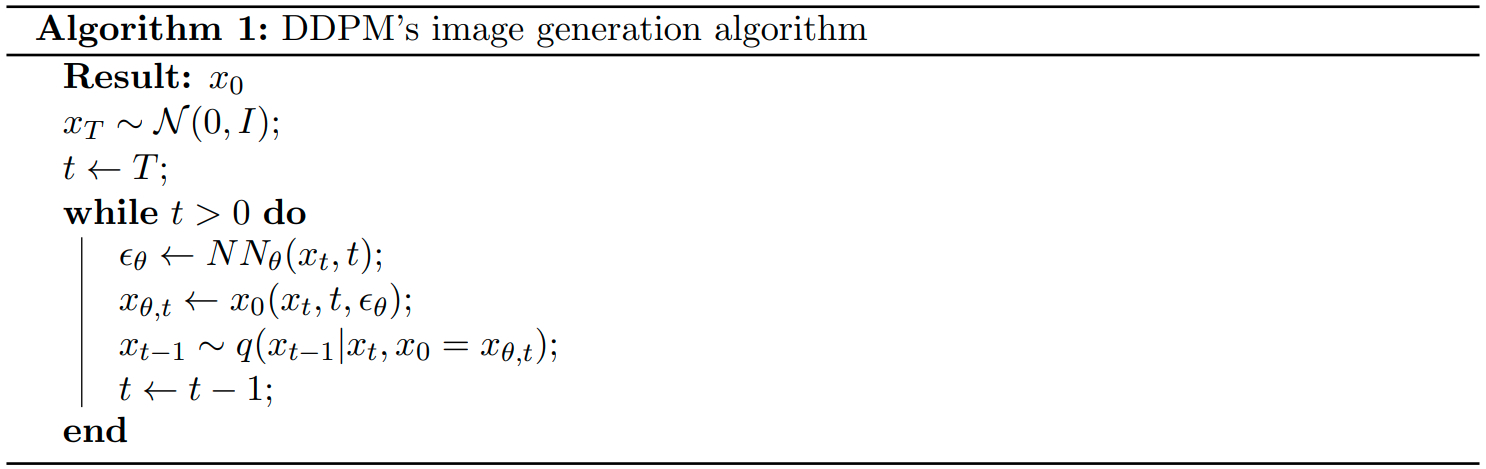

### $x_0$ parametrization vs $\epsilon$ parametrization (0.5 pts)

>  $q(x_t|x_{t+1}, x_0)$ <-> $x_t = c_{x_{t+1}} x_{t+1} + c_{x_0} x_0 + \sigma_t \epsilon$
>> So to get your scores definitely find $c_{x_{t+1}}, c_{x_0}$ 

>> How $x_0(x_t, t, \epsilon_{\theta})$ is look like? If your ddpm's neural net was trained on "x_0" parametrization, how can you get $\epsilon_{\theta}$ ?

>>> From $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$ we get
>>> $x_0(x_t,t,\epsilon_\theta)=\dfrac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}$.
>>> Symmetrically, if the network predicts $x_0^\theta$, the noise can be recovered as
>>> $\epsilon_\theta(x_t,t)=\dfrac{x_t-\sqrt{\bar\alpha_t}\,x_0^\theta(x_t,t)}{\sqrt{1-\bar\alpha_t}}$.

>> What would be different in algorithm, if NN was trained on "x_0" parametrization?

>>> The reverse chain is the same: at each step we still sample from $q(x_{t-1}|x_t,x_0=x_0^\theta)$ using the same posterior coefficients $c_{x_t},c_{x_0},\sigma_t$. The only differences are: (1) the network output is interpreted directly as $x_0^\theta$ (no need to invert $\epsilon\!\to\!x_0$), and (2) the training target in the MSE loss is $x_0$ instead of $\epsilon$. Whenever a downstream formula needs $\epsilon_\theta$ (DDIM step, classifier guidance), we convert $x_0^\theta\!\to\!\epsilon_\theta$ via the formula above.

In this work it's expected you will experiment with two parametrization, if you don't, scores will be halfed

In [6]:
from torch import nn


def get_coeffs_primitives(
    T: int = 1000,
    beta_min: float = 1e-4,
    beta_max: float = 2e-2,
    betas: Optional[Tensor] = None
) -> Dict[str, Tensor]:
    """
    output: Dict[str, Tensor]
      {
        "a": b
      }
    ---
    b.shape == (T,)
    """
    if betas is None:
        betas = torch.linspace(beta_min, beta_max, T, dtype=torch.float32)
    else:
        betas = betas.detach().clone().float()
        T = betas.shape[0]

    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat(
        [torch.ones(1, dtype=alphas_cumprod.dtype), alphas_cumprod[:-1]],
        dim=0
    )

    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod)
    sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod - 1.0)

    # posterior q(x_{t-1} | x_t, x_0) variance and mean coefficients
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_sigma = torch.sqrt(torch.clamp(posterior_variance, min=0.0))
    posterior_log_variance_clipped = torch.log(torch.clamp(posterior_variance, min=1e-20))
    # mean = posterior_x_0_coef * x_0 + posterior_x_t_coef * x_t
    posterior_x_0_coef = (
        betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    )
    posterior_x_t_coef = (
        torch.sqrt(alphas) * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    )

    return {
        "betas": betas,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "alphas_cumprod_prev": alphas_cumprod_prev,
        "sqrt_alphas_cumprod": sqrt_alphas_cumprod,
        "sqrt_one_minus_alphas_cumprod": sqrt_one_minus_alphas_cumprod,
        "sqrt_recip_alphas_cumprod": sqrt_recip_alphas_cumprod,
        "sqrt_recipm1_alphas_cumprod": sqrt_recipm1_alphas_cumprod,
        "posterior_variance": posterior_variance,
        "posterior_log_variance_clipped": posterior_log_variance_clipped,
        "posterior_x_0_coef": posterior_x_0_coef,
        "posterior_x_t_coef": posterior_x_t_coef,
        "posterior_sigma": posterior_sigma,
    }


def extract_values_from_times(values: Tensor, times: torch.LongTensor) -> Tensor:
    values = values[times]
    return values[:, None, None, None]


`DDPMDynamic`: (1 pts)
- `__init__` - get coefficients, add them to the class as attributes, so we can access them by name without using a dictionary
- `sample_from_posterior_q(x_t: FloatTensor, x_0: FloatTensor, t: LongTensor)` - $ x_{t-1} \sim q(x_{t-1} | x_{t}, x_0) $
- `get_eps_from_x_zero(x_t: FloatTensor, x_0: FloatTensor, t: LongTensor)` - $\epsilon(x_t, x_0, t)$
- `get_x_zero(x_t: FloatTensor, eps: FloatTensor, t: LongTensor)` - $x_0(x_t, \epsilon, t)$
- `forward` - $ x_{t} \sim q(x_t | x_0) $

This module don't know about parametrization, it's usage is only for operating with $x_0, \epsilon, x_t, t$ 

In [7]:
class DDPMDynamic(nn.Module):
    def __init__(
        self,
        T: int = 1000,
        beta_min: float = 1e-4,
        beta_max: float = 2e-2,
    ):
        super().__init__()
        self.T = T

        coeffs_primitives = get_coeffs_primitives(T, beta_min, beta_max)

        for name, tensor in coeffs_primitives.items():
            self.register_buffer(name, tensor)

    def sample_time_on_device(self, batch_size: int = 1, device: torch.device = torch.device('cpu')):
        return torch.randint(0, self.T, (batch_size,), device=device)

    def sample_from_posterior_q(
        self,
        x_t: Tensor,
        x_0: Tensor,
        t: torch.LongTensor
    ) -> Tensor:
        # x_{t-1} ~ q(x_{t-1} | x_t, x_0) = N(c_x0 * x_0 + c_xt * x_t, sigma^2 * I)
        posterior_x_0_coef = extract_values_from_times(self.posterior_x_0_coef, t)
        posterior_x_t_coef = extract_values_from_times(self.posterior_x_t_coef, t)
        posterior_sigma = extract_values_from_times(self.posterior_sigma, t)

        mean = posterior_x_0_coef * x_0 + posterior_x_t_coef * x_t
        eps = torch.randn_like(x_t)
        # at t == 0 posterior_sigma == 0, so the result is deterministic
        return mean + posterior_sigma * eps

    def get_eps_from_x_zero(
        self,
        x_t: Tensor,
        x_0: Tensor,
        t: torch.LongTensor
    ) -> Tensor:
        # x_t = sqrt(alpha_bar) * x_0 + sqrt(1 - alpha_bar) * eps  =>
        #   eps = (x_t - sqrt(alpha_bar) * x_0) / sqrt(1 - alpha_bar)
        sqrt_alphas_cumprod = extract_values_from_times(self.sqrt_alphas_cumprod, t)
        sqrt_one_minus_alphas_cumprod = extract_values_from_times(
            self.sqrt_one_minus_alphas_cumprod, t
        )
        return (x_t - sqrt_alphas_cumprod * x_0) / sqrt_one_minus_alphas_cumprod

    def get_x_zero(
        self,
        x_t: Tensor,
        eps: Tensor,
        t: torch.LongTensor
    ) -> Tensor:
        # x_0 = (x_t - sqrt(1 - alpha_bar) * eps) / sqrt(alpha_bar)
        sqrt_alphas_cumprod = extract_values_from_times(self.sqrt_alphas_cumprod, t)
        sqrt_one_minus_alphas_cumprod = extract_values_from_times(
            self.sqrt_one_minus_alphas_cumprod, t
        )
        return (x_t - sqrt_one_minus_alphas_cumprod * eps) / sqrt_alphas_cumprod

    def forward(self, batch: Dict[str, Tensor]) -> Dict[str, Tensor]:
        """
            Dict:
                x_0 - clean_image
                t - time (int \in [0; T - 1])
                eps - Optional[corresponding noise]
        Returns:
            Dict:
                x_t - noised_sample
                eps - corresponding noise
        """
        x_0 = batch['x_0']
        t = batch.get('t')
        if t is None:
            t = self.sample_time_on_device(x_0.shape[0], x_0.device)
        else:
            t = t.to(device=x_0.device, dtype=torch.long)

        eps = batch.get('eps')
        if eps is None:
            eps = torch.randn_like(x_0)
        else:
            eps = eps.to(device=x_0.device, dtype=x_0.dtype)

        sqrt_alphas_cumprod = extract_values_from_times(self.sqrt_alphas_cumprod, t)
        sqrt_one_minus_alphas_cumprod = extract_values_from_times(
            self.sqrt_one_minus_alphas_cumprod, t
        )
        x_t = sqrt_alphas_cumprod * x_0 + sqrt_one_minus_alphas_cumprod * eps

        return {'x_0': x_0, 't': t, 'eps': eps, 'x_t': x_t}

<>:63: SyntaxWarning: invalid escape sequence '\i'
<>:63: SyntaxWarning: invalid escape sequence '\i'
/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_95483/550234919.py:63: SyntaxWarning: invalid escape sequence '\i'
  """


In [8]:
def check_ddpm_dynamic():
    dynamic = DDPMDynamic()
    device = torch.device('mps:0')
    dynamic.to(device)
    times = dynamic.sample_time_on_device(10, device)
    assert times.device == device, f'{times.device}, {device}'
    assert times.shape == (10,)

check_ddpm_dynamic()

In [9]:
target_coeffs = torch.load('coeffs_dict.pth', map_location='cpu')
calc_coeffs = get_coeffs_primitives()
assert torch.allclose(calc_coeffs["posterior_x_0_coef"], target_coeffs["posterior_x_0_coef"])
assert torch.allclose(calc_coeffs["posterior_x_t_coef"], target_coeffs["posterior_x_t_coef"])

### `Sampler`/DDPM's cycle: (1 pts / 0.5 pts)
- `single_step` - you need to sample $x_{t-1} \sim p(x_{t-1}|x_t)$
- `sample` - the entire process of traversing the Markov sampling chain

Here you need to implement sampling for two ddpm's parametrizations

In [10]:
from tqdm.auto import trange


class Sampler(nn.Module):
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic,
        parametrization: str = 'eps' # either `eps` or `x_0`
    ):
        super().__init__()
        ddpm.eval()
        self.ddpm = ddpm
        self.dynamic = dynamic
        assert parametrization in ['eps', 'x_0']
        self.parametrization = parametrization

    @torch.no_grad()
    def single_step(self, x_t, t):
        if isinstance(t, int):
            t = torch.full((x_t.shape[0],), t, device=x_t.device, dtype=torch.long)
        else:
            t = t.to(device=x_t.device, dtype=torch.long)

        model_out = self.ddpm(x_t, t)
        # convert model output to x_0 regardless of parametrization
        if self.parametrization == 'eps':
            x_0 = self.dynamic.get_x_zero(x_t, model_out, t)
        else:
            x_0 = model_out

        return self.dynamic.sample_from_posterior_q(x_t, x_0, t)

    @torch.no_grad()
    def sample(
        self,
        shape: Tuple[int, int, int, int],
        device: torch.device = torch.device('cpu'),
        verbose: bool = False
    ) -> Tensor:
        x_t = torch.randn(shape, device=device)
        iterator = trange(self.dynamic.T - 1, -1, -1) if verbose else range(self.dynamic.T - 1, -1, -1)

        for time in iterator:
            t = torch.full((shape[0],), time, device=device, dtype=torch.long)
            x_t = self.single_step(x_t, t)

        return x_t


### DDPM's training (0.5 pts)

> In `DiffusionTrainer` you should pay attention to `calc_loss` method you need implement, it's not expected to extensively experiment with different loss weightnings, simple `.mean()` in right place is enough
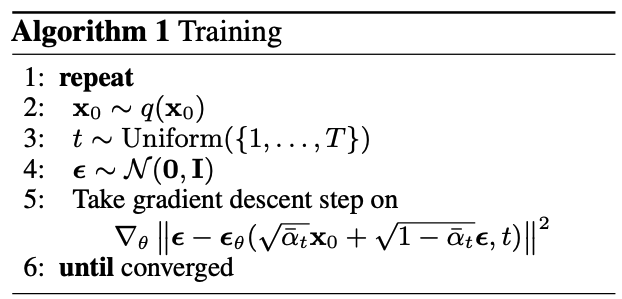

In [11]:
from torch_ema import ExponentialMovingAverage
import wandb
import math
import torchvision


class DiffusionTrainer:
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic,
        device: torch.device = torch.device('cpu'),
        parametrization: str = 'eps',
    ):
        self.ddpm = ddpm
        self.dynamic = dynamic

        self.dynamic.to(device)
        self.ddpm.to(device)

        self.sampler = Sampler(ddpm, dynamic, parametrization=parametrization)
        self.sampler.to(device)
        self.parametrization = parametrization

        self.ema = ExponentialMovingAverage(ddpm.parameters(), decay=0.999)

        self.device = device


        self.optimizer = torch.optim.AdamW(
            self.ddpm.parameters(),
            lr=2e-4,
            weight_decay=1e-2
        )

        self.step = 0

    def switch_to_ema(self) -> None:
        self.ema.store(self.ddpm.parameters())
        self.ema.copy_to(self.ddpm.parameters())

    def switch_back_from_ema(self) -> None:
        self.ema.restore(self.ddpm.parameters())

    def calc_loss(self, x_0: torch.Tensor) -> torch.Tensor:
        x_0 = x_0.to(self.device)
        batch_size = x_0.shape[0]

        t = self.dynamic.sample_time_on_device(batch_size, self.device)
        eps = torch.randn_like(x_0)
        dynamic_out = self.dynamic({'x_0': x_0, 't': t, 'eps': eps})
        x_t = dynamic_out['x_t']

        model_out = self.ddpm(x_t, t)
        if self.parametrization == 'eps':
            target = eps
        else:
            target = x_0

        return ((model_out - target) ** 2).mean()

    def log_metric(self, metric_name: str, loader_name: str, value: Union[float, torch.Tensor, wandb.Image]):
        wandb.log({f'{metric_name}/{loader_name}': value}, step=self.step)

    def optimizer_logic(self, loss: torch.Tensor) -> None:
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.ema.update(self.ddpm.parameters())

    def train(
        self,
        train_generator: Generator[Dict[str, Tensor], None, None],
        total_iters: int = 5000,
        project_name: str = 'discrete_time_ddpm',
        experiment_name: str = 'mnist_baseline'
    ) -> None:
        session = wandb.init(project=project_name, name=experiment_name)

        self.ddpm.train()

        for iter_idx in trange(1, 1 + total_iters):
            self.step = iter_idx

            batch = next(train_generator)
            batch = dict_to_device(batch, device=self.device)

            loss = self.calc_loss(x_0=batch['images'])
            self.log_metric('mse', 'train', loss)

            self.optimizer_logic(loss)

            if iter_idx % 1000 == 0:
                self.snapshot()

        self.ddpm.eval()
        self.switch_to_ema()

        session.finish()

    @torch.no_grad()
    def sample_images(
            self, batch_size: int,
            verbose: bool = False
    ) -> torch.Tensor:
        x_pred = self.sampler.sample((batch_size, 1, 32, 32), self.device, verbose)
        x_pred = postprocess_image(x_pred)
        return x_pred

    @torch.no_grad()
    def snapshot(self) -> None:
        prev_mode = self.ddpm.training

        self.ddpm.eval()
        self.switch_to_ema()

        images = self.sample_images(100).cpu()
        nrow = 10
        grid = torchvision.utils.make_grid(images, nrow=nrow).permute(1, 2, 0)
        grid = grid.data.numpy().astype(np.uint8)
        self.log_metric('images', 'from_noise', wandb.Image(grid))

        self.switch_back_from_ema()
        self.ddpm.train(prev_mode)

In [12]:
from denoising_diffusion_pytorch import Unet

_use_flash_attn = torch.cuda.is_available()

ddpm = Unet(
    dim=64,
    dim_mults=(1, 2, 4, 4),
    channels=1,
    flash_attn=True
)

In [13]:
device = torch.device('mps:0')

In [14]:
trainer = DiffusionTrainer(
    ddpm,
    DDPMDynamic(),
    device,
    parametrization='x_0'
)

In [15]:
generator = get_train_images_generator(128)

In [16]:
import os
os.environ.setdefault('WANDB_MODE', 'offline')
os.environ.setdefault('WANDB_SILENT', 'true')

batch_size = 128
generator = get_train_images_generator(batch_size)

In [17]:
total_iters = 5000

trainer.train(
    generator,
    total_iters=total_iters,
    project_name='discrete_time_ddpm',
    experiment_name=f'mnist_{trainer.parametrization}_baseline',
)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

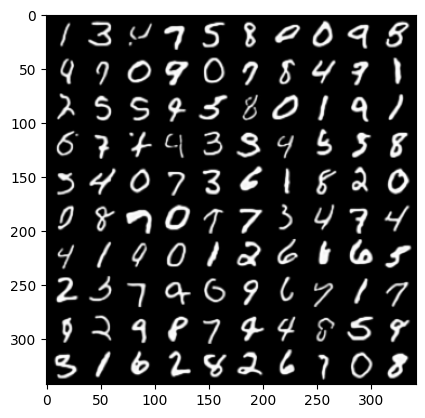

In [18]:
from matplotlib import pyplot as plt
import math

@torch.inference_mode()
def sample_images(
    sampler: Sampler, batch_size: int = 100,
    device = torch.device('cpu'),
    verbose: bool = True
):
    images = sampler.sample((batch_size, 1, 32, 32), device, True)
    images = postprocess_image(images)
    images = images.cpu()
    nrow = int(math.ceil(math.sqrt(batch_size)))
    grid = torchvision.utils.make_grid(images, nrow=nrow).permute(1, 2, 0)
    grid = grid.data.numpy().astype(np.uint8)
    return grid

grid = sample_images(trainer.sampler, 100, trainer.device)

plt.imshow(grid)

In [19]:
import os

CKPT_DIR = 'ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)


def _ckpt_path(parametrization: str) -> str:
    return os.path.join(CKPT_DIR, f'ddpm_{parametrization}.pth')

torch.save(ddpm.state_dict(), _ckpt_path(trainer.parametrization))
print(f'Saved {trainer.parametrization} checkpoint to {_ckpt_path(trainer.parametrization)}')

if trainer.parametrization == 'x_0':
    ddpm_x0 = ddpm
else:
    ddpm_eps = ddpm

Saved x_0 checkpoint to ckpts/ddpm_x_0.pth


In [20]:
other_parametrization = 'eps' if trainer.parametrization == 'x_0' else 'x_0'
other_ckpt = _ckpt_path(other_parametrization)

ddpm_other = Unet(
    dim=64,
    dim_mults=(1, 2, 4, 4),
    channels=1,
    flash_attn=_use_flash_attn,
)

if os.path.exists(other_ckpt):
    ddpm_other.load_state_dict(torch.load(other_ckpt, map_location='cpu'))
    ddpm_other.to(device).eval()
    print(f'Loaded {other_parametrization} checkpoint from {other_ckpt}')
else:
    trainer_other = DiffusionTrainer(
        ddpm_other,
        DDPMDynamic(),
        device,
        parametrization=other_parametrization,
    )
    generator_other = get_train_images_generator(batch_size)
    trainer_other.train(
        generator_other,
        total_iters=total_iters,
        project_name='discrete_time_ddpm',
        experiment_name=f'mnist_{other_parametrization}_baseline',
    )
    torch.save(ddpm_other.state_dict(), other_ckpt)
    print(f'Saved {other_parametrization} checkpoint to {other_ckpt}')

if other_parametrization == 'eps':
    ddpm_eps = ddpm_other
else:
    ddpm_x0 = ddpm_other

  0%|          | 0/5000 [00:00<?, ?it/s]

Saved eps checkpoint to ckpts/ddpm_eps.pth


### Classifer-guidance sampling (2 pts)

#### Some intuition for classifier-guidance sampling (0.5 pts)

>> $\nabla_x \log p(x | y) = \nabla_x \log p(x) + \nabla_x \log p(y | x) $

>> $\nabla_{x_t} \log p_{\theta}(x_t, t) = \dfrac{-\epsilon_{\theta}(x_t, t)}{\sqrt{1 - \bar{\alpha}_t}}$

>> So in fact, when you use ddpm for $x_0, \epsilon$, etc. prediction, you step in the "score" direction, score - gradient of log probability by x

>>> Simplify terms in $x_{t-1}$ prediction by $x_t$, $\epsilon_{\theta}$ to see that "score" of the classifier is used with positive coefficent

>>> Plugging $x_0^\theta(x_t,t)=\dfrac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta}{\sqrt{\bar\alpha_t}}$ into the DDPM posterior mean and using $\alpha_t=1-\beta_t$, $\bar\alpha_t=\bar\alpha_{t-1}\alpha_t$, the mean reduces to $\mu_\theta(x_t,t)=\dfrac{1}{\sqrt{\alpha_t}}\!\left(x_t-\dfrac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta\right)$.
>>> Since $\nabla_{x_t}\log p_\theta(x_t,t)=-\epsilon_\theta/\sqrt{1-\bar\alpha_t}$, the same mean reads $\mu_\theta=\dfrac{1}{\sqrt{\alpha_t}}\!\left(x_t+\beta_t\,\nabla_{x_t}\log p_\theta(x_t,t)\right)$ — the score appears with a strictly positive coefficient $\beta_t/\sqrt{\alpha_t}$. Replacing the unconditional score by $\nabla_{x_t}\log p_\theta(x_t,t)+\gamma\nabla_{x_t}\log p_\phi(y|x_t,t)$ adds the classifier score with the same positive weight, i.e. classifier guidance pushes the chain toward higher probability of class $y$.

>> So now you know that sampling can be rewritten in the form with "score", what if you use cond. score inplace of standard? You need to define - what is $\nabla_{x_t} \log p(y | x_t)$
>>> Let's just train classifier which must get $x_t$ and return logits of classes from training set. Logits then are casted to log probabilities, you calculating gradint from one selected log prob by $x_t$

>> Show how $\epsilon_{\theta, \phi}, x_{0}^{\theta, \phi}$ prediction will change with "score" from classifier $\phi$ ?
>>> First take the unconditional prediction. If the network outputs $x_0^\theta$, convert to $\epsilon_\theta=\dfrac{x_t-\sqrt{\bar\alpha_t}\,x_0^\theta}{\sqrt{1-\bar\alpha_t}}$. Then merge with the classifier score:
>>> $\epsilon_{\theta,\phi}(x_t,t,y)=\epsilon_\theta(x_t,t)-\gamma\sqrt{1-\bar\alpha_t}\,\nabla_{x_t}\log p_\phi(y|x_t,t)$.
>>> Equivalently
>>> $x_{0}^{\theta,\phi}(x_t,t,y)=\dfrac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_{\theta,\phi}}{\sqrt{\bar\alpha_t}}=x_0^\theta+\dfrac{\gamma(1-\bar\alpha_t)}{\sqrt{\bar\alpha_t}}\nabla_{x_t}\log p_\phi(y|x_t,t)$.
>>> The reverse step is then taken with $\epsilon_{\theta,\phi}$ (or, equivalently, $x_0^{\theta,\phi}$).

>>> In practice inplace of $\nabla_x \log p(x | y) = \nabla_x \log p(x) + \nabla_x \log p(y | x)$, people use $\nabla_x \log p(x | y) = \nabla_x \log p(x) + T \nabla_x \log p(y | x)$, where $T$ - some positive coeffs to adjust condition

In [21]:
!git clone https://github.com/openai/guided-diffusion.git guided
%cd guided
!pip3 install -v -e .
%cd ..

fatal: destination path 'guided' already exists and is not an empty directory.
/Users/danila.biktimirov/Downloads/guided
Using pip 25.1.1 from /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip (python 3.12)
Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///Users/danila.biktimirov/Downloads/guided
  Installing build dependencies ...   Running command pip subprocess to install build dependencies
  Using pip 25.1.1 from /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip (python 3.12)
    Obtaining dependency information for setuptools>=40.8.0 from https://files.pythonhosted.org/packages/9d/76/f789f7a86709c6b087c5a2f52f911838cad707cc613162401badc665acfe/setuptools-82.0.1-py3-none-any.whl.metadata
    Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  ERROR: pip's dependency resolver does not currently ta

In [22]:
from guided.guided_diffusion.unet import EncoderUNetModel


class NoisyClassifier(nn.Module):
    def __init__(
        self,
    ):
        super().__init__()
        self.noisy_classifier = EncoderUNetModel(
            image_size=32,
            in_channels=1,
            model_channels=32,
            out_channels=10,
            num_res_blocks=2,
            attention_resolutions=(2, 2),
            pool='spatial'
        )
        self.noisy_classifier.out = nn.Sequential(
            nn.Linear(1472, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x_t, t):
        return self.noisy_classifier(x_t, t)

In [23]:
noisy_classifier = NoisyClassifier()
noisy_classifier(torch.randn(10, 1, 32, 32), torch.randn(10)).shape

torch.Size([10, 10])

#### `GuidanceSampler` (1.5 pts)

* `get_eps_theta_phi(x_t: Tensor, t: torch.LongTensor, y: torch.LongTensor)` - calculate simple unconditional $\epsilon_{\theta}$, then adjust it with "score" from noisy-classifier
    * to get from model's output gradient of input in torch, you should use `torch.autograd.grad`
* `single_step`, `sample` - have the same logic as simple unconditional sampler

In [24]:
class GuidanceSampler(nn.Module):
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic,
        noisy_classifier: nn.Module,
        gamma: float = 1, # temperature for scaling score from noisy-classifier
        parametrization: str = 'eps'
    ):
        super().__init__()
        self.ddpm = ddpm
        self.dynamic = dynamic
        self.noisy_classifier = noisy_classifier
        self.gamma = gamma
        assert parametrization in ['eps', 'x_0']
        self.parametrization = parametrization

    @torch.no_grad()
    def get_eps_theta_phi(self, x_t: Tensor, t: torch.LongTensor, y: torch.LongTensor):
        if isinstance(t, int):
            t = torch.full((x_t.shape[0],), t, device=x_t.device, dtype=torch.long)
        else:
            t = t.to(device=x_t.device, dtype=torch.long)
        y = y.to(device=x_t.device, dtype=torch.long)

        model_out = self.ddpm(x_t, t)
        if self.parametrization == 'eps':
            eps_theta = model_out
        else:
            eps_theta = self.dynamic.get_eps_from_x_zero(x_t, model_out, t)

        with torch.enable_grad():
            x_in = x_t.detach().requires_grad_(True)
            logits = self.noisy_classifier(x_in, t)
            log_probs = torch.log_softmax(logits, dim=1)
            selected_log_probs = log_probs[torch.arange(x_t.shape[0], device=x_t.device), y].sum()
            classifier_score = torch.autograd.grad(selected_log_probs, x_in)[0]

        sqrt_one_minus_alpha_bar = extract_values_from_times(
            self.dynamic.sqrt_one_minus_alphas_cumprod, t
        )
        return eps_theta - self.gamma * sqrt_one_minus_alpha_bar * classifier_score

    @torch.no_grad()
    def single_step(self, x_t: Tensor, t: torch.LongTensor, y: torch.LongTensor) -> Tensor:
        if isinstance(t, int):
            t = torch.full((x_t.shape[0],), t, device=x_t.device, dtype=torch.long)
        else:
            t = t.to(device=x_t.device, dtype=torch.long)

        eps = self.get_eps_theta_phi(x_t, t, y)
        x_0 = self.dynamic.get_x_zero(x_t, eps, t)
        return self.dynamic.sample_from_posterior_q(x_t, x_0, t)

    @torch.no_grad()
    def sample(
        self,
        shape: Tuple[int, int, int, int],
        y: torch.LongTensor,
        device: torch.device = torch.device('cpu'),
        verbose: bool = False
    ) -> Tensor:
        x_t = torch.randn(shape, device=device)
        y = y.to(device=device, dtype=torch.long)
        iterator = trange(self.dynamic.T - 1, -1, -1) if verbose else range(self.dynamic.T - 1, -1, -1)

        for time in iterator:
            t = torch.full((shape[0],), time, device=device, dtype=torch.long)
            x_t = self.single_step(x_t, t, y)

        return x_t

In [25]:
from torch.nn.functional import cross_entropy


class NoisyClassifierTrainer:
    def __init__(
        self,
        ddpm: nn.Module,
        classifier: nn.Module,
        dynamic: DDPMDynamic,
        gamma: float = 1,
        device: torch.device = torch.device('cpu'),
        parametrization: str = 'eps'
    ):
        self.classifier = classifier
        self.dynamic = dynamic

        self.dynamic.to(device)
        self.classifier.to(device)

        self.device = device

        self.optimizer = torch.optim.AdamW(
            self.classifier.parameters(),
            lr=2e-4,
            weight_decay=1e-2
        )
        for param in ddpm.parameters():
            param.requires_grad = False
        ddpm.eval()

        self.sampler = GuidanceSampler(
            ddpm, dynamic, classifier, gamma, parametrization
        )
        self.sampler.to(device)

        self.step = 0

    def calc_loss(self, x_0: torch.Tensor, y: torch.Tensor) -> Dict[str, torch.Tensor]:
        x_0 = x_0.to(self.device)
        y = y.to(self.device, dtype=torch.long)
        batch_size = x_0.shape[0]

        t = self.dynamic.sample_time_on_device(batch_size, self.device)
        eps = torch.randn_like(x_0)
        x_t = self.dynamic({'x_0': x_0, 't': t, 'eps': eps})['x_t']

        logits = self.classifier(x_t, t)
        loss = cross_entropy(logits, y)
        accuracy = (logits.argmax(dim=1) == y).float().mean()
        return {'loss': loss, 'accuracy': accuracy}

    def log_metric(self, metric_name: str, loader_name: str, value: Union[float, torch.Tensor, wandb.Image]):
        wandb.log({f'{metric_name}/{loader_name}': value}, step=self.step)

    def optimizer_logic(self, loss: torch.Tensor) -> None:
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(
        self,
        train_generator: Generator[Dict[str, Tensor], None, None],
        val_loader: DataLoader,
        total_iters: int = 1000,
        project_name: str = 'discrete_time_ddpm',
        experiment_name: str = 'noisy_classifier'
    ) -> None:
        session = wandb.init(project=project_name, name=experiment_name)

        self.classifier.train()

        for iter_idx in trange(1, 1 + total_iters):
            self.step = iter_idx

            batch = next(train_generator)
            batch = dict_to_device(batch, device=self.device)

            outs = self.calc_loss(x_0=batch['images'], y=batch['targets'])
            self.log_metric('CE', 'train', outs['loss'])
            self.log_metric('accuracy', 'train', outs['accuracy'])

            self.optimizer_logic(outs['loss'])

            if iter_idx % 500000 == 0:
                self.validate(val_loader)
                self.snapshot()
        self.classifier.eval()
        session.finish()

    @torch.no_grad()
    def validate(self, val_loader: DataLoader) -> None:
        prev_mode = self.classifier.training
        self.classifier.eval()
        total_acc = 0
        total_loss = 0
        total_count = 0
        for batch in val_loader:
            batch = dict_to_device(batch, self.device)
            outs = self.calc_loss(x_0=batch['images'], y=batch['targets'])
            total_acc += outs['accuracy'] * batch['images'].shape[0]
            total_loss += outs['loss'] * batch['images'].shape[0]
            total_count += batch['images'].shape[0]

        acc = total_acc / total_count
        loss = total_loss / total_count
        self.log_metric(f'accuracy', 'valid', acc)
        self.log_metric(f'CE', 'valid', loss)
        self.classifier.train(prev_mode)


    @torch.no_grad()
    def sample_images(
            self,
            y: torch.LongTensor,
            verbose: bool = False
    ) -> torch.Tensor:
        batch_size = len(y)
        x_pred = self.sampler.sample((batch_size, 1, 32, 32), y, self.device, verbose)
        x_pred = postprocess_image(x_pred)
        return x_pred

    @torch.no_grad()
    def snapshot(self) -> None:
        prev_mode = self.classifier.training
        self.classifier.eval()

        y = torch.arange(10)[:, None].expand(-1, 10).reshape(-1).to(self.device)
        images = self.sample_images(y).cpu()
        nrow = 10
        grid = torchvision.utils.make_grid(images, nrow=nrow).permute(1, 2, 0)
        grid = grid.data.numpy().astype(np.uint8)
        self.log_metric('images', 'from_noise', wandb.Image(grid))

        self.classifier.train(prev_mode)


In [26]:
nc_trainer = NoisyClassifierTrainer(
    ddpm,
    noisy_classifier,
    DDPMDynamic(),
    device=device,
    parametrization='x_0'
)

In [27]:
nc_trainer.train(
    generator,
    DataLoader(
        dataset=MnistDataset(train=False),
        batch_size=128,
        num_workers=0,
        shuffle=False,
        drop_last=False
    ),
    total_iters=2500
)

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

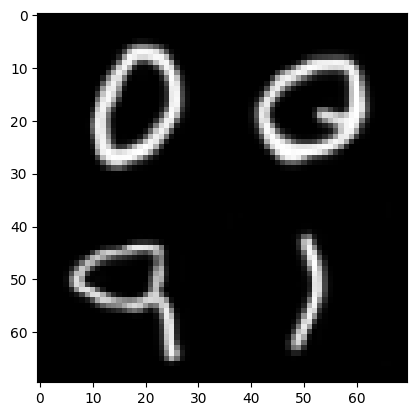

In [28]:
from matplotlib import pyplot as plt
import math

@torch.no_grad()
def sample_images_with_cond(
    sampler: GuidanceSampler,
    condition: Optional[torch.LongTensor] = None,
    device = torch.device('cpu'),
    verbose: bool = True
):
    if condition is not None:
        y = condition
    else:
        y = torch.arange(2)[:, None].expand(-1, 2).reshape(-1)
    y = y.to(device)
    batch_size = len(y)
    images = sampler.sample((batch_size, 1, 32, 32), y, device, True)
    images = postprocess_image(images)
    images = images.cpu()
    nrow = int(math.ceil(math.sqrt(batch_size)))
    grid = torchvision.utils.make_grid(images, nrow=nrow).permute(1, 2, 0)
    grid = grid.data.numpy().astype(np.uint8)
    return grid

nc_trainer.sampler.noisy_classifier.eval()
grid = sample_images_with_cond(nc_trainer.sampler, device=trainer.device)

plt.imshow(grid)

## DDIM sampling (2 pts) ([src](https://arxiv.org/pdf/2010.02502.pdf))

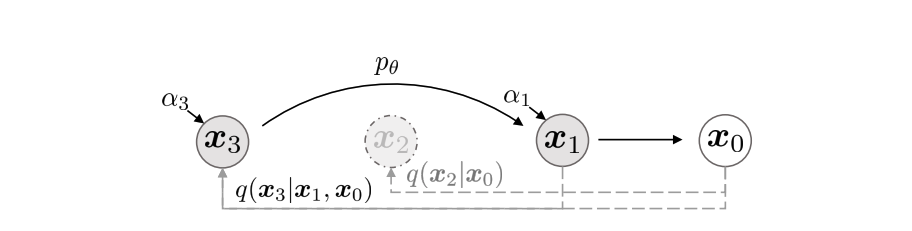

This approach allow ddpm's users skip some steps (with change of coefficients, not just delete step in ddpm chain). With this you can use fewer steps when $t$ ~ T, and more steps when $t$ ~ 0. Some works research different scheduling for $t$ moments to make ddpm steps, but standard case - is to use uniform shortened list of times - transit on K times between steps 

### DDIM dynamic

Single step in DDIM dynamic looks like: 

$x_{t_k} \sim q(x_{t-k}|x_t, x_0=x_0^{\theta})$

$x_{t-k} \sim \mathcal{N}(x_{t-k} | \sqrt{\bar{\alpha}_{t-k}}x_0^{\theta}(x_t, t) + \sqrt{1 - \bar{\alpha}_{t-k} - \sigma_t^2}\epsilon_{\theta}(x_t, t), \sigma_t^2 I)$

$x_{t-k} = \sqrt{\bar{\alpha}_{t-k}}x_0^{\theta}(x_t, t) + \sqrt{1 - \bar{\alpha}_{t-k} - \sigma_t^2}\epsilon_{\theta}(x_t, t) + \epsilon \sigma_t, \quad \sigma_t$ - coefficient for controlling determinism of chain

From $x_0^{\theta}$ you can get $\epsilon_{\theta}$ and vice versa

#### `DeterministicDynamic` (0.5 pts)
* In this module it's not expected to accelerate chain
* `mean_of_posterior_q` - mean of $q(x_{t-1}|x_t, x_0=x_0^{\theta})$
* `sample_from_posterior_q` - just simple mean of $q(x_{t-1}|x_t, x_0=x_0^{\theta})$

In [29]:
class DeterministicDynamic(DDPMDynamic):
    def mean_of_posterior_q(
        self,
        x_t: Tensor,
        x_0: Tensor,
        t: torch.LongTensor
    ) -> Tensor:
        posterior_x_0_coef = extract_values_from_times(self.posterior_x_0_coef, t)
        posterior_x_t_coef = extract_values_from_times(self.posterior_x_t_coef, t)
        return posterior_x_0_coef * x_0 + posterior_x_t_coef * x_t

    def sample_from_posterior_q(
        self,
        x_t: Tensor,
        x_0: Tensor,
        t: torch.LongTensor
    ):
        return self.mean_of_posterior_q(x_t, x_0, t)


  0%|          | 0/1000 [00:00<?, ?it/s]

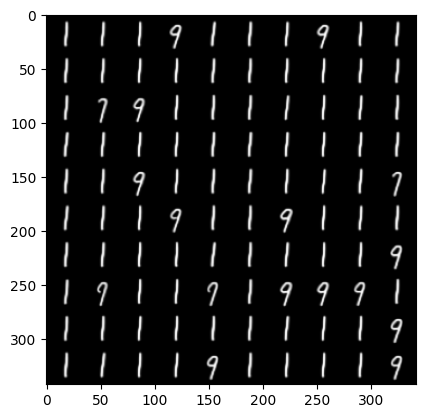

In [30]:
determ_sampler = Sampler(ddpm, DeterministicDynamic().to(device), parametrization='x_0')

grid = sample_images(determ_sampler, 100, device)

plt.imshow(grid)

## Accelerating ddpm chain via DDIM (1.5 pts)

* You can use already existing modules in help or create new one
* Implement DDIM with uniformly shortened list of times - make step in K moments in time at once, example: 9 -> 5 -> 1 -> 0

In [31]:
class DDIMSampler(nn.Module):
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic,
        parametrization: str = 'eps',
        num_steps: Optional[int] = None,
        speedup: int = 1,
        eta: float = 0.0,
    ):
        super().__init__()
        ddpm.eval()
        self.ddpm = ddpm
        self.dynamic = dynamic
        assert parametrization in ['eps', 'x_0']
        self.parametrization = parametrization
        assert eta >= 0
        self.eta = float(eta)

        if num_steps is None:
            assert speedup >= 1
            num_steps = max(1, math.ceil(dynamic.T / speedup))
        self.num_steps = min(int(num_steps), dynamic.T)

    def make_schedule(self, device: torch.device) -> torch.LongTensor:
        times = torch.linspace(self.dynamic.T - 1, 0, steps=self.num_steps, device=device).round().long()
        times = torch.unique_consecutive(times)
        if times[-1].item() != 0:
            times = torch.cat([times, torch.zeros(1, device=device, dtype=torch.long)])
        return times

    def _alpha_bar(self, t: torch.LongTensor, dtype: torch.dtype) -> Tensor:
        values = torch.ones(t.shape[0], device=t.device, dtype=dtype)
        mask = t >= 0
        if mask.any():
            values[mask] = self.dynamic.alphas_cumprod[t[mask]].to(dtype=dtype)
        return values[:, None, None, None]

    @torch.no_grad()
    def predict_x0_eps(self, x_t: Tensor, t: torch.LongTensor, **kwargs) -> Tuple[Tensor, Tensor]:
        model_out = self.ddpm(x_t, t)
        if self.parametrization == 'eps':
            eps = model_out
            x_0 = self.dynamic.get_x_zero(x_t, eps, t)
        else:
            x_0 = model_out
            eps = self.dynamic.get_eps_from_x_zero(x_t, x_0, t)
        return x_0, eps

    @torch.no_grad()
    def single_step(self, x_t: Tensor, t: torch.LongTensor, prev_t: torch.LongTensor, **kwargs) -> Tensor:
        t = t.to(device=x_t.device, dtype=torch.long)
        prev_t = prev_t.to(device=x_t.device, dtype=torch.long)

        x_0, eps = self.predict_x0_eps(x_t, t, **kwargs)
        alpha_bar_prev = self._alpha_bar(prev_t, x_t.dtype)
        alpha_bar_t = self._alpha_bar(t, x_t.dtype)

        sigma = self.eta * torch.sqrt(
            torch.clamp((1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t), min=0.0)
            * torch.clamp(1.0 - alpha_bar_t / alpha_bar_prev, min=0.0)
        )
        direction = torch.sqrt(torch.clamp(1.0 - alpha_bar_prev - sigma ** 2, min=0.0)) * eps
        noise = torch.randn_like(x_t) if self.eta > 0 else torch.zeros_like(x_t)
        return torch.sqrt(alpha_bar_prev) * x_0 + direction + sigma * noise

    @torch.no_grad()
    def sample(
        self,
        shape: Tuple[int, int, int, int],
        device: torch.device = torch.device('cpu'),
        verbose: bool = False
    ) -> Tensor:
        x_t = torch.randn(shape, device=device)
        times = self.make_schedule(device)
        iterator = trange(len(times)) if verbose else range(len(times))

        for idx in iterator:
            time = times[idx]
            prev_time = times[idx + 1] if idx + 1 < len(times) else torch.tensor(-1, device=device)
            t = torch.full((shape[0],), int(time.item()), device=device, dtype=torch.long)
            prev_t = torch.full((shape[0],), int(prev_time.item()), device=device, dtype=torch.long)
            x_t = self.single_step(x_t, t, prev_t)

        return x_t


class DDIMGuidanceSampler(DDIMSampler):
    def __init__(
        self,
        ddpm: nn.Module,
        dynamic: DDPMDynamic,
        noisy_classifier: nn.Module,
        gamma: float = 1,
        parametrization: str = 'eps',
        num_steps: Optional[int] = None,
        speedup: int = 1,
        eta: float = 0.0,
    ):
        super().__init__(ddpm, dynamic, parametrization, num_steps, speedup, eta)
        self.noisy_classifier = noisy_classifier
        self.gamma = gamma

    @torch.no_grad()
    def predict_x0_eps(self, x_t: Tensor, t: torch.LongTensor, y: torch.LongTensor, **kwargs) -> Tuple[Tensor, Tensor]:
        guidance_sampler = GuidanceSampler(
            self.ddpm,
            self.dynamic,
            self.noisy_classifier,
            gamma=self.gamma,
            parametrization=self.parametrization,
        ).to(x_t.device)
        eps = guidance_sampler.get_eps_theta_phi(x_t, t, y)
        x_0 = self.dynamic.get_x_zero(x_t, eps, t)
        return x_0, eps

    @torch.no_grad()
    def sample(
        self,
        shape: Tuple[int, int, int, int],
        y: torch.LongTensor,
        device: torch.device = torch.device('cpu'),
        verbose: bool = False
    ) -> Tensor:
        x_t = torch.randn(shape, device=device)
        y = y.to(device=device, dtype=torch.long)
        times = self.make_schedule(device)
        iterator = trange(len(times)) if verbose else range(len(times))

        for idx in iterator:
            time = times[idx]
            prev_time = times[idx + 1] if idx + 1 < len(times) else torch.tensor(-1, device=device)
            t = torch.full((shape[0],), int(time.item()), device=device, dtype=torch.long)
            prev_t = torch.full((shape[0],), int(prev_time.item()), device=device, dtype=torch.long)
            x_t = self.single_step(x_t, t, prev_t, y=y)

        return x_t

DDIM schedule length: 100


  0%|          | 0/100 [00:00<?, ?it/s]

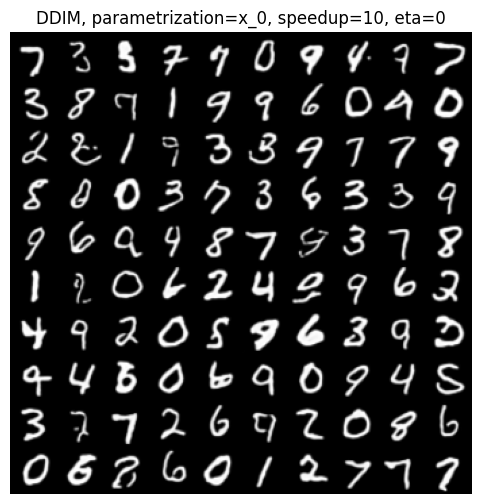

In [32]:
ddim_sampler = DDIMSampler(
    ddpm=ddpm,
    dynamic=DDPMDynamic().to(device),
    parametrization=trainer.parametrization,
    speedup=10,
    eta=0.0,
).to(device)

print('DDIM schedule length:', len(ddim_sampler.make_schedule(device)))
grid = sample_images(ddim_sampler, 100, device)

plt.figure(figsize=(6, 6))
plt.imshow(grid)
plt.axis('off')
plt.title(f'DDIM, parametrization={trainer.parametrization}, speedup=10, eta=0')
plt.show()

## Results (7 pts)
Demonstrate images generated from (3.4 pts):
* unconditional sampling with eps/x_0 parametrization (0.2 pts)
* conditional sampling with eps/x_0 parametrization with at least 3 not close temperatues (0.2 pts)
* deterministic unconditional sampling with eps/x_0 parametrization (0.2 pts)
* deterministic conditional sampling with eps/x_0 parametrization at least 3 not close temperatues (0.2 pts)

* accelerated unconditional sampling with eps/x_0 parametrization in 5, 10, 25, 50, 100, 200 times (1.2 pts)
* accelerated conditional sampling with eps/x_0 parametrization in 5, 10, 25, 50, 100, 200 times (1.2 pts)

In [38]:
trained_ddpm_models = {}
trained_ddpm_models[trainer.parametrization] = ddpm

if 'ddpm_eps' in globals():
    trained_ddpm_models['eps'] = ddpm_eps
if 'ddpm_x0' in globals():
    trained_ddpm_models['x_0'] = ddpm_x0

speedups = [5, 10, 25, 50, 100, 200]
guidance_gammas = [0.3, 1.0, 3.0]
condition_100 = torch.arange(10).repeat_interleave(10).to(device)


def show_grid(grid, title: str, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(grid)
    plt.axis('off')
    plt.title(title)
    plt.show()


def make_uncond_sampler(model, parametrization: str, deterministic: bool = False):
    dynamic = DeterministicDynamic() if deterministic else DDPMDynamic()
    return Sampler(model, dynamic.to(device), parametrization=parametrization).to(device)


def make_cond_sampler(model, parametrization: str, gamma: float, deterministic: bool = False):
    dynamic = DeterministicDynamic() if deterministic else DDPMDynamic()
    return GuidanceSampler(model, dynamic.to(device), noisy_classifier, gamma=gamma, parametrization=parametrization).to(device)


def make_ddim_sampler(model, parametrization: str, speedup: int, eta: float = 0.0):
    return DDIMSampler(model, DDPMDynamic().to(device), parametrization=parametrization, speedup=speedup, eta=eta).to(device)


def make_ddim_cond_sampler(model, parametrization: str, speedup: int, gamma: float, eta: float = 0.0):
    return DDIMGuidanceSampler(model, DDPMDynamic().to(device), noisy_classifier, gamma=gamma, parametrization=parametrization, speedup=speedup, eta=eta).to(device)

  0%|          | 0/1000 [00:00<?, ?it/s]

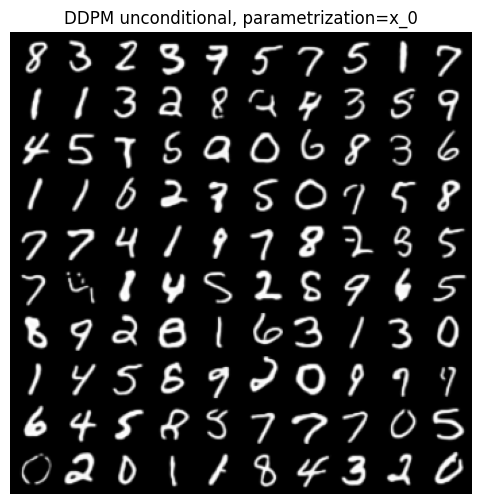

  0%|          | 0/1000 [00:00<?, ?it/s]

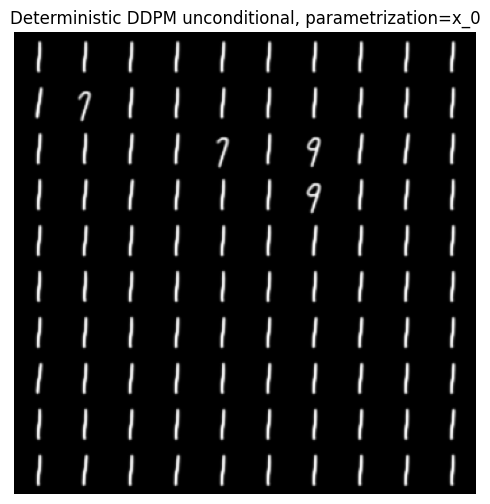

  0%|          | 0/1000 [00:00<?, ?it/s]

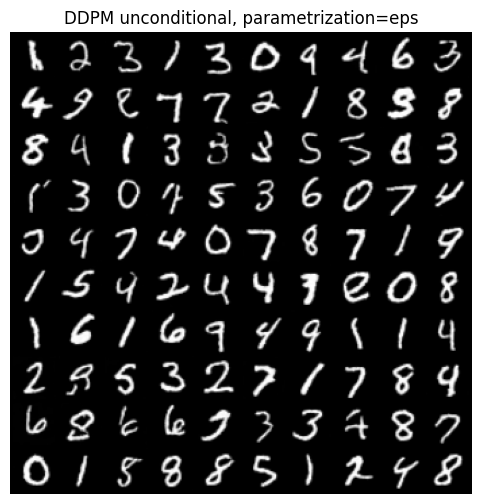

  0%|          | 0/1000 [00:00<?, ?it/s]

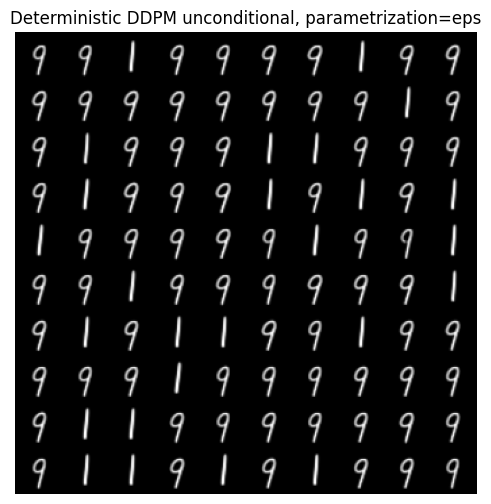

In [34]:
for parametrization, model in trained_ddpm_models.items():
    model.eval()
    sampler = make_uncond_sampler(model, parametrization, deterministic=False)
    grid = sample_images(sampler, 100, device)
    show_grid(grid, f'DDPM unconditional, parametrization={parametrization}')

    sampler = make_uncond_sampler(model, parametrization, deterministic=True)
    grid = sample_images(sampler, 100, device)
    show_grid(grid, f'Deterministic DDPM unconditional, parametrization={parametrization}')

  0%|          | 0/1000 [00:00<?, ?it/s]

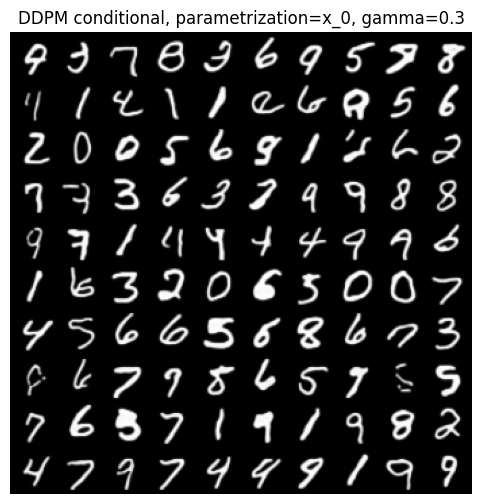

  0%|          | 0/1000 [00:00<?, ?it/s]

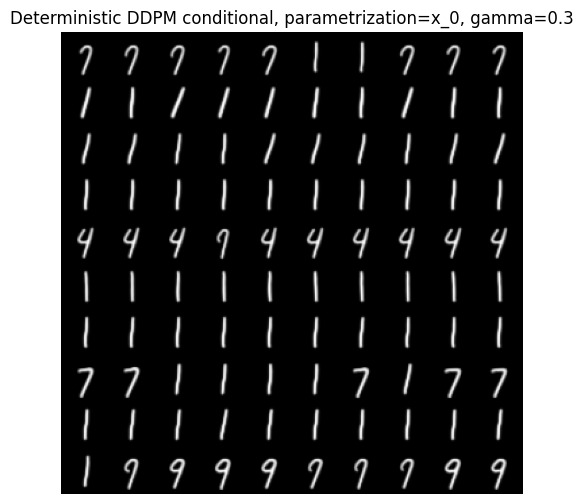

  0%|          | 0/1000 [00:00<?, ?it/s]

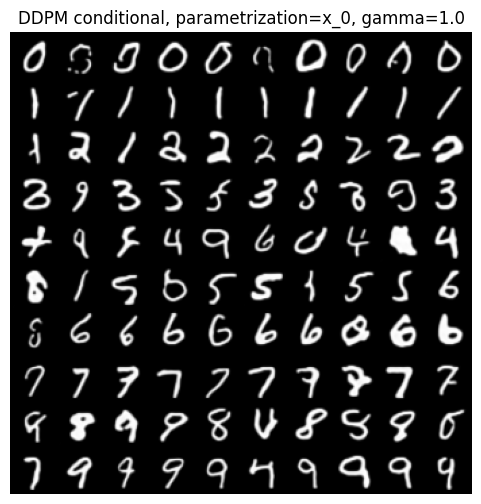

  0%|          | 0/1000 [00:00<?, ?it/s]

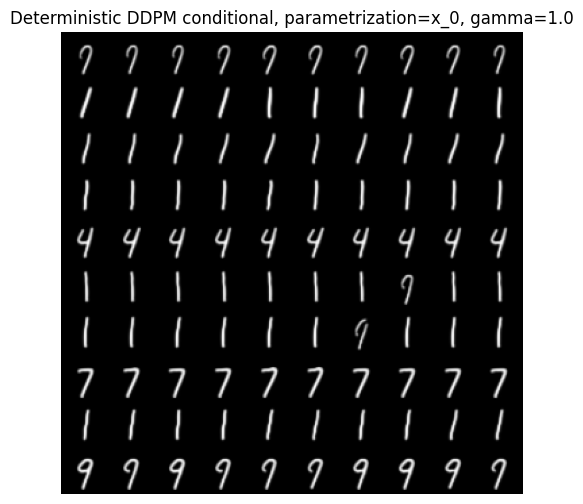

  0%|          | 0/1000 [00:00<?, ?it/s]

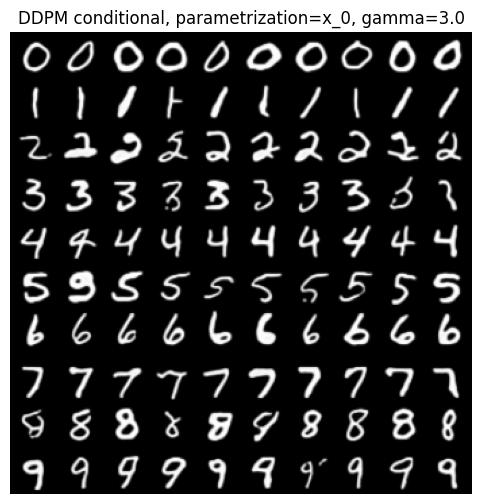

  0%|          | 0/1000 [00:00<?, ?it/s]

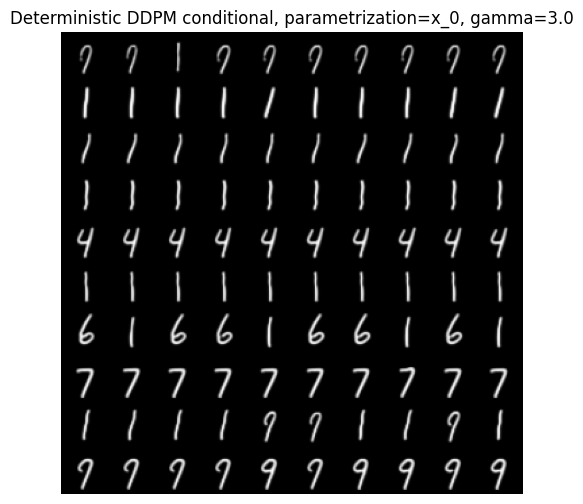

  0%|          | 0/1000 [00:00<?, ?it/s]

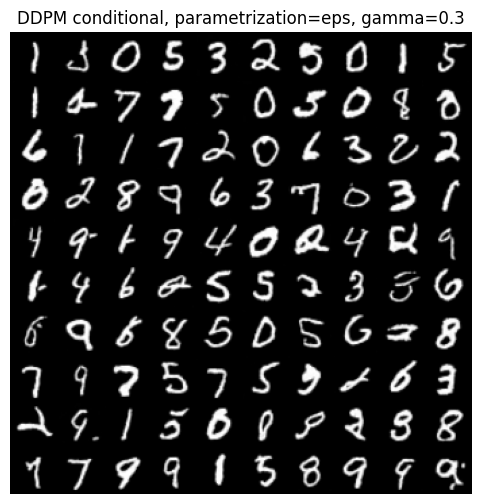

  0%|          | 0/1000 [00:00<?, ?it/s]

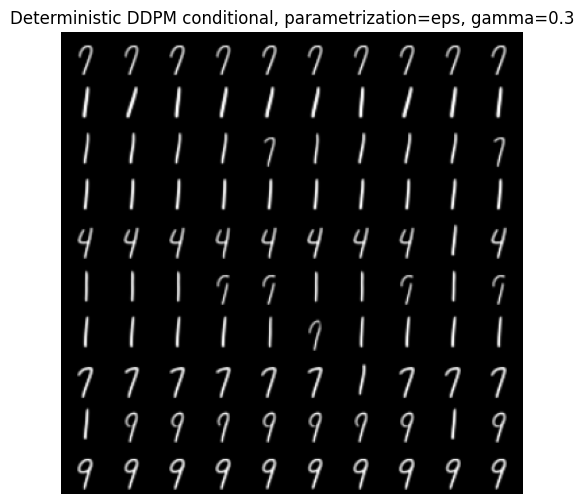

  0%|          | 0/1000 [00:00<?, ?it/s]

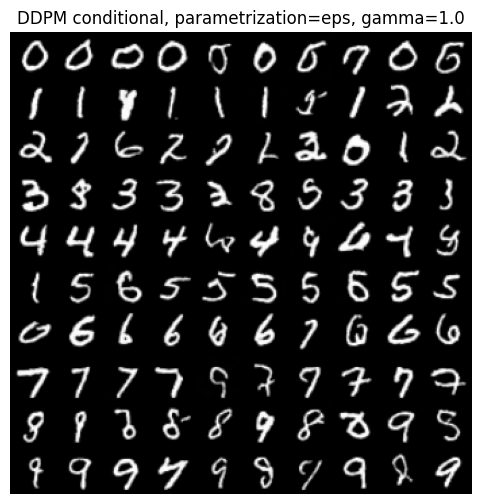

  0%|          | 0/1000 [00:00<?, ?it/s]

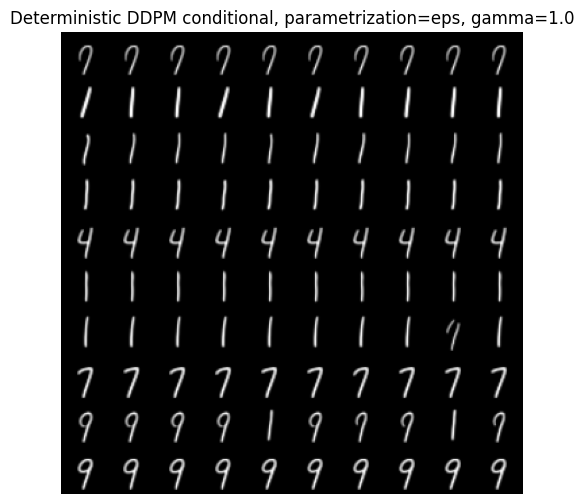

  0%|          | 0/1000 [00:00<?, ?it/s]

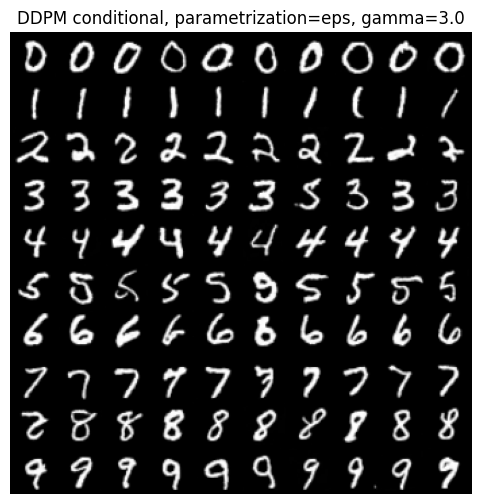

  0%|          | 0/1000 [00:00<?, ?it/s]

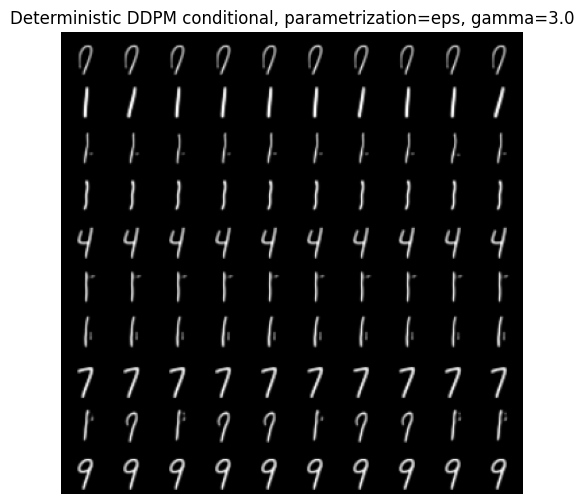

In [35]:
noisy_classifier.eval()

for parametrization, model in trained_ddpm_models.items():
    model.eval()
    for gamma in guidance_gammas:
        sampler = make_cond_sampler(model, parametrization, gamma=gamma, deterministic=False)
        grid = sample_images_with_cond(sampler, condition_100, device)
        show_grid(grid, f'DDPM conditional, parametrization={parametrization}, gamma={gamma}')

        sampler = make_cond_sampler(model, parametrization, gamma=gamma, deterministic=True)
        grid = sample_images_with_cond(sampler, condition_100, device)
        show_grid(grid, f'Deterministic DDPM conditional, parametrization={parametrization}, gamma={gamma}')

  0%|          | 0/200 [00:00<?, ?it/s]

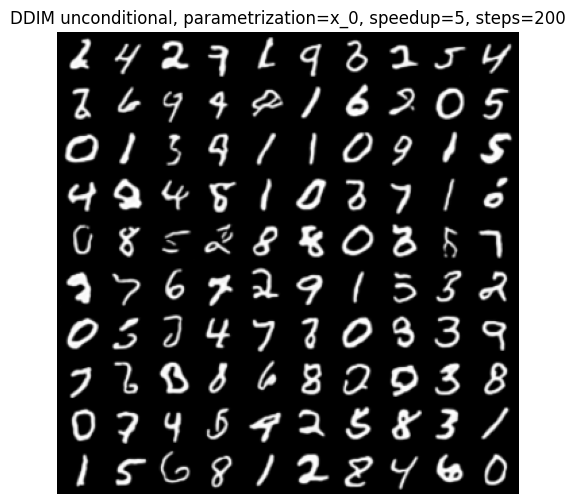

  0%|          | 0/100 [00:00<?, ?it/s]

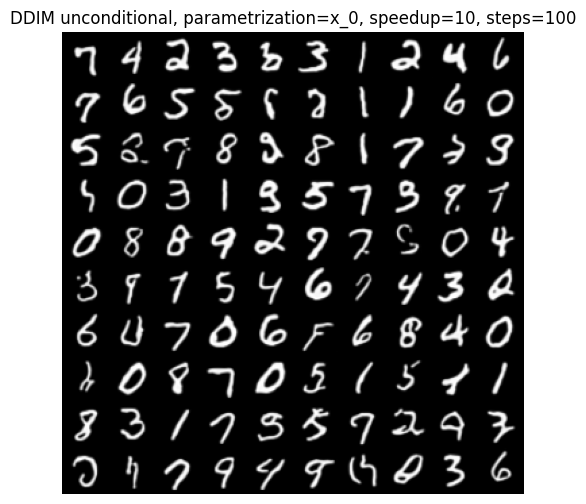

  0%|          | 0/40 [00:00<?, ?it/s]

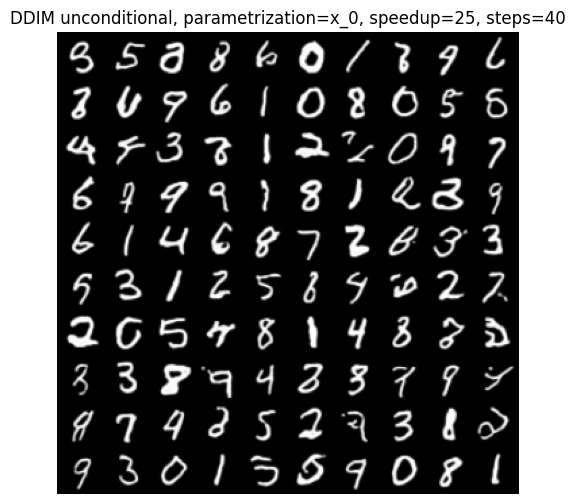

  0%|          | 0/20 [00:00<?, ?it/s]

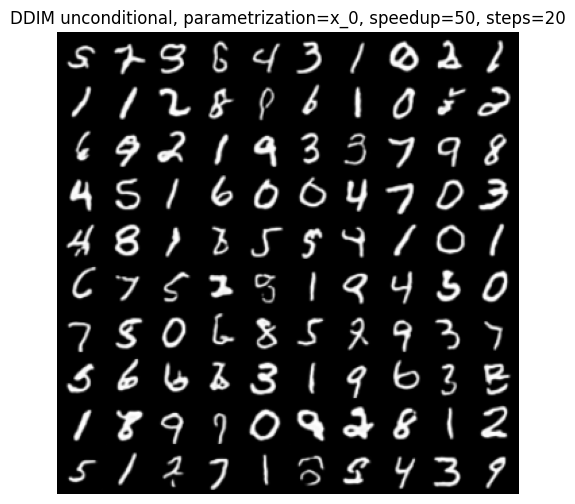

  0%|          | 0/10 [00:00<?, ?it/s]

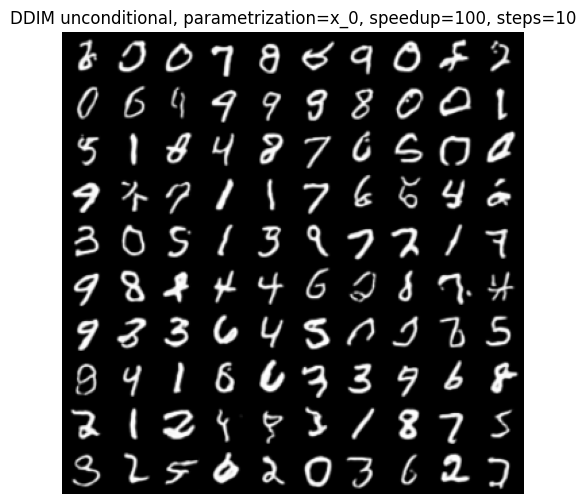

  0%|          | 0/5 [00:00<?, ?it/s]

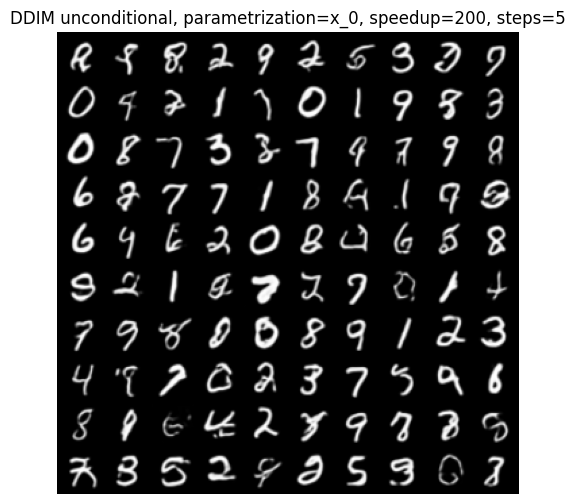

  0%|          | 0/200 [00:00<?, ?it/s]

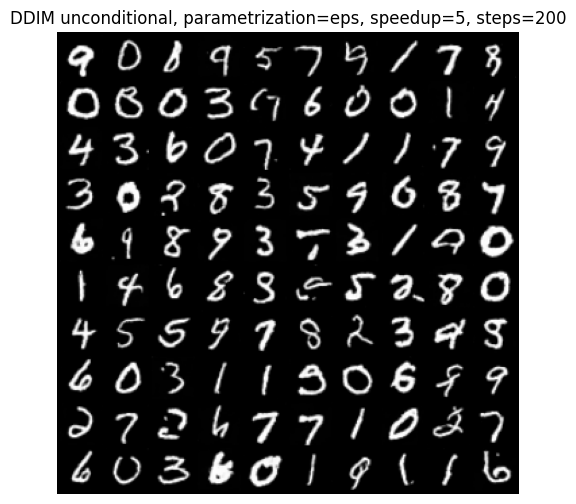

  0%|          | 0/100 [00:00<?, ?it/s]

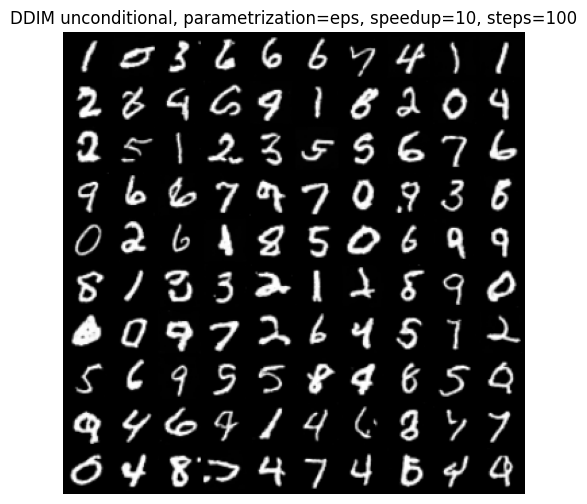

  0%|          | 0/40 [00:00<?, ?it/s]

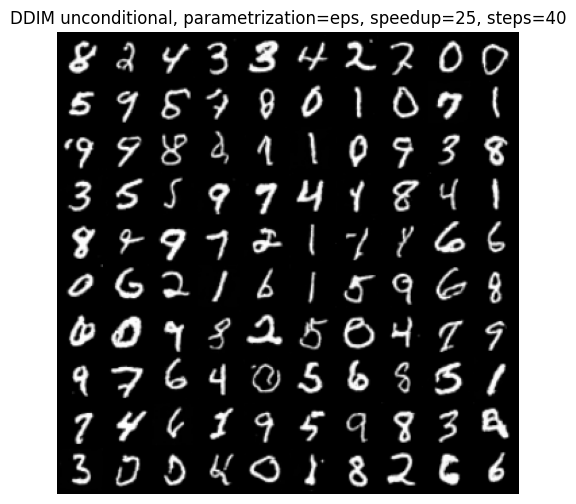

  0%|          | 0/20 [00:00<?, ?it/s]

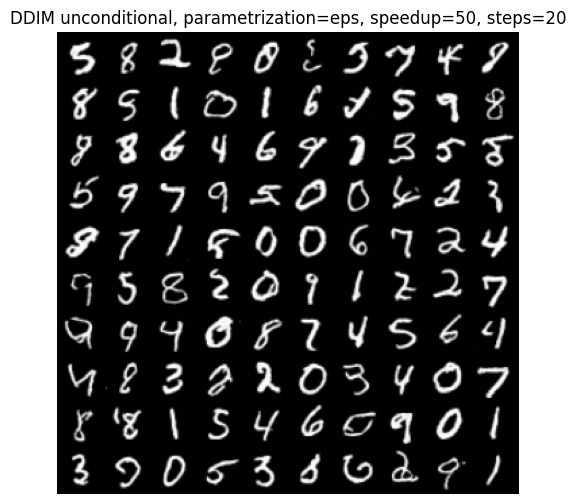

  0%|          | 0/10 [00:00<?, ?it/s]

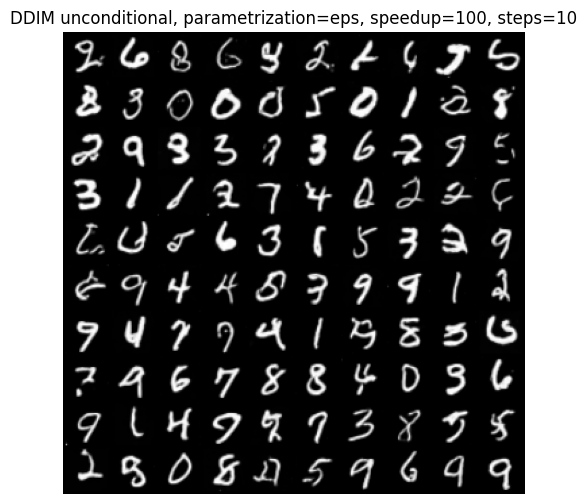

  0%|          | 0/5 [00:00<?, ?it/s]

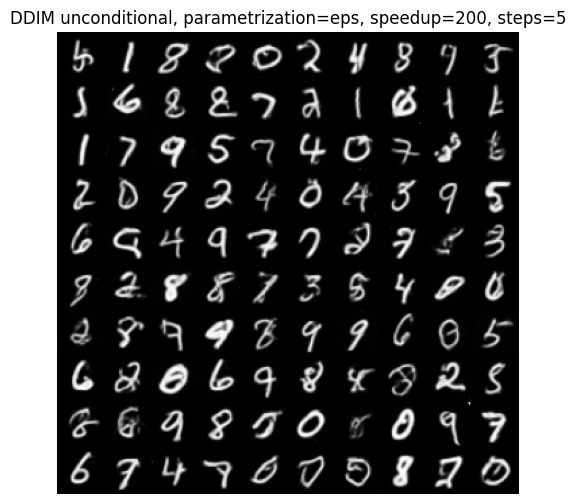

In [36]:
for parametrization, model in trained_ddpm_models.items():
    model.eval()
    for speedup in speedups:
        sampler = make_ddim_sampler(model, parametrization=parametrization, speedup=speedup, eta=0.0)
        grid = sample_images(sampler, 100, device)
        schedule_len = len(sampler.make_schedule(device))
        show_grid(grid, f'DDIM unconditional, parametrization={parametrization}, speedup={speedup}, steps={schedule_len}')

  0%|          | 0/200 [00:00<?, ?it/s]

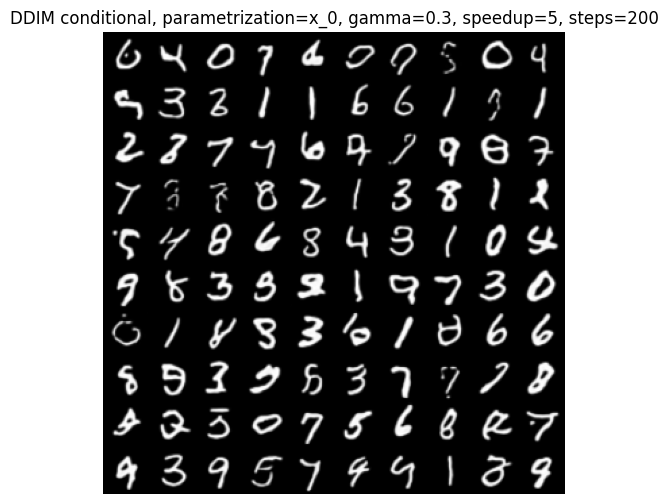

  0%|          | 0/100 [00:00<?, ?it/s]

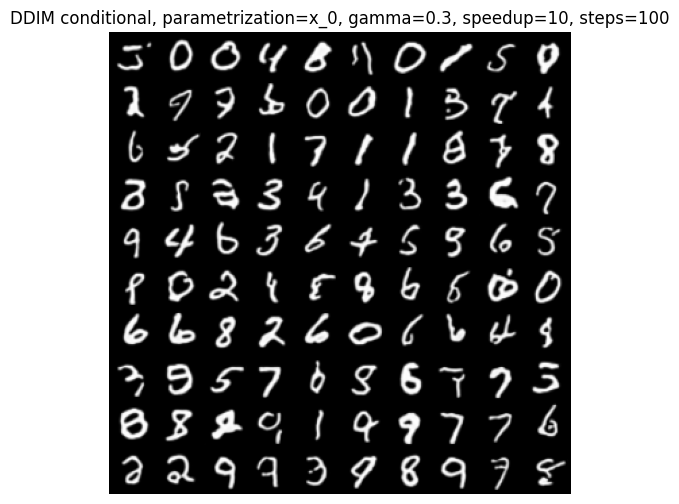

  0%|          | 0/40 [00:00<?, ?it/s]

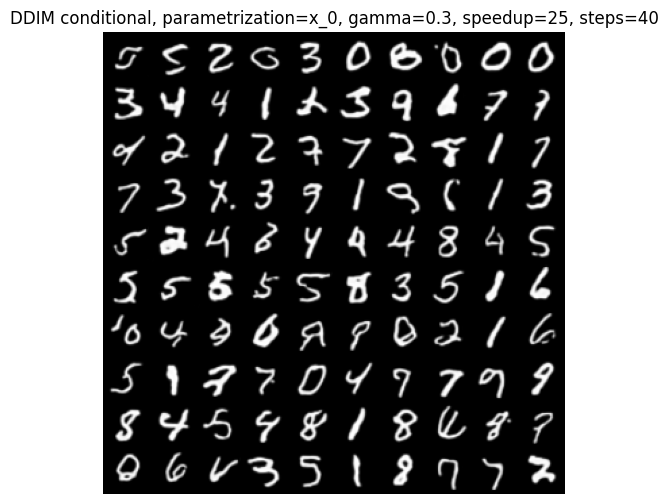

  0%|          | 0/20 [00:00<?, ?it/s]

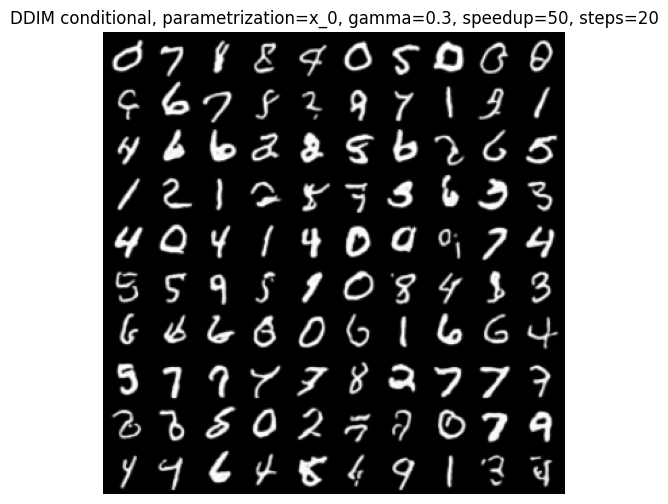

  0%|          | 0/10 [00:00<?, ?it/s]

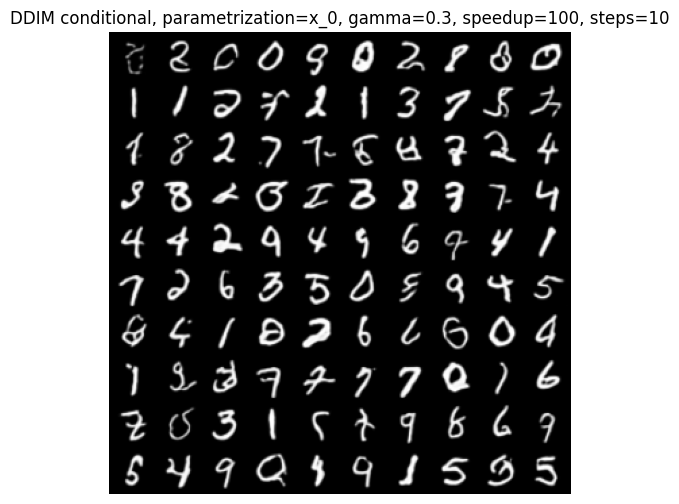

  0%|          | 0/5 [00:00<?, ?it/s]

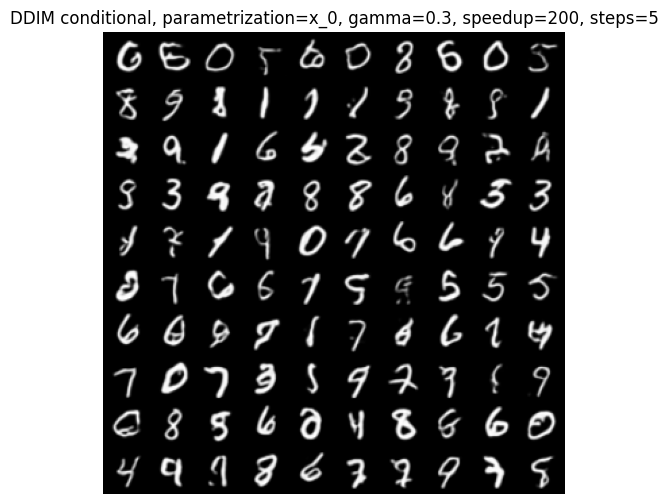

  0%|          | 0/200 [00:00<?, ?it/s]

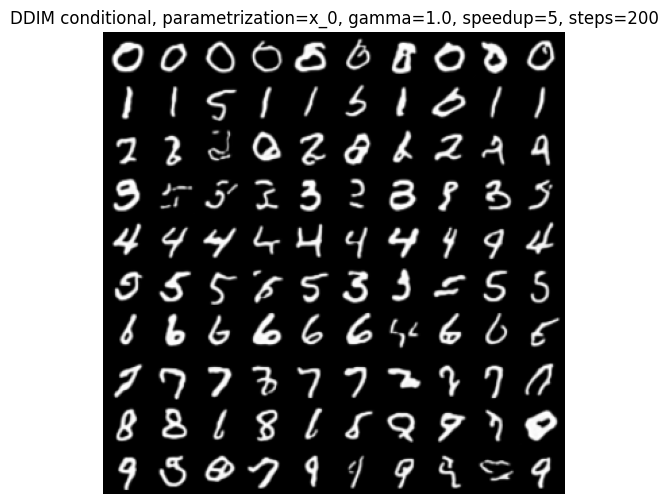

  0%|          | 0/100 [00:00<?, ?it/s]

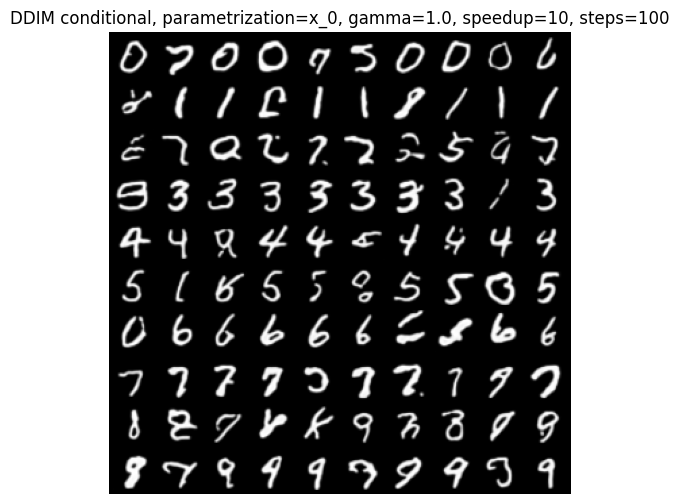

  0%|          | 0/40 [00:00<?, ?it/s]

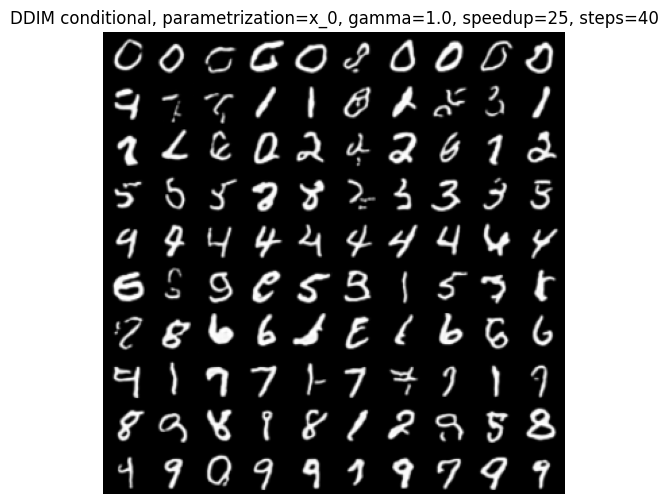

  0%|          | 0/20 [00:00<?, ?it/s]

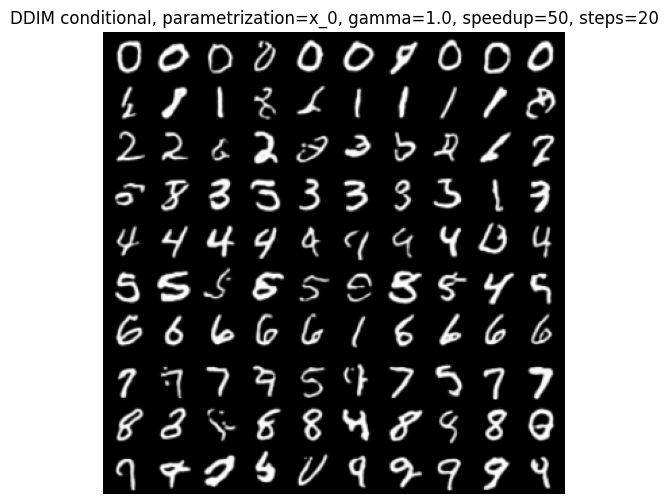

  0%|          | 0/10 [00:00<?, ?it/s]

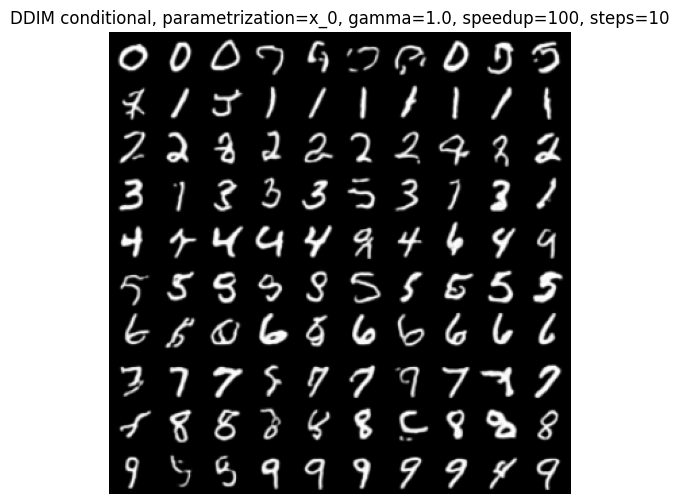

  0%|          | 0/5 [00:00<?, ?it/s]

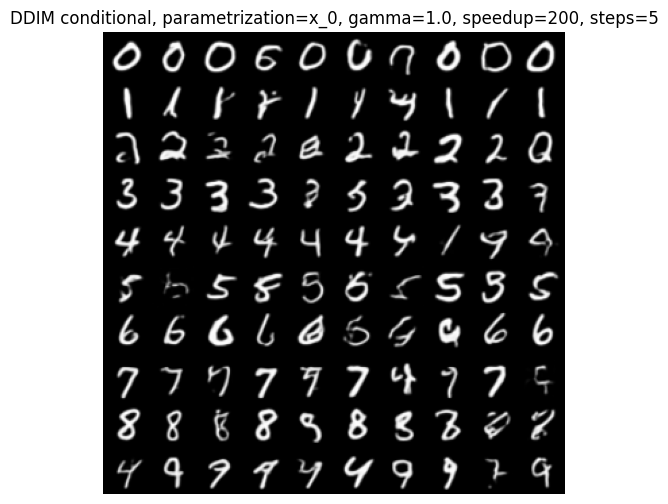

  0%|          | 0/200 [00:00<?, ?it/s]

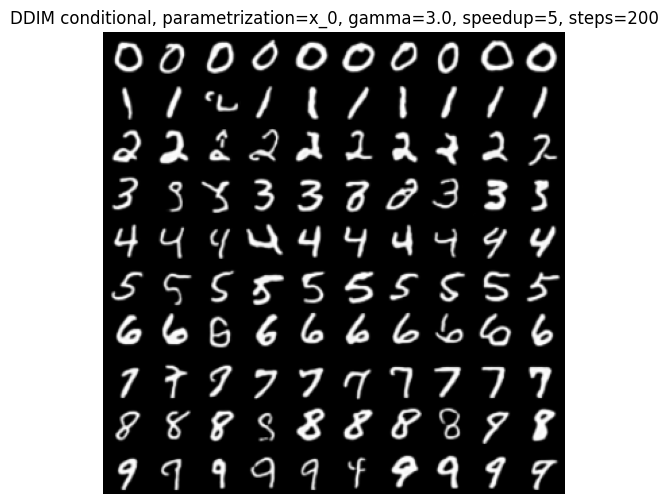

  0%|          | 0/100 [00:00<?, ?it/s]

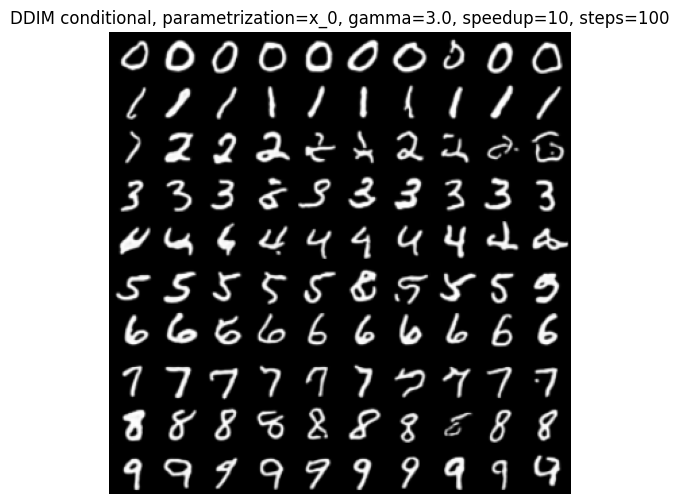

  0%|          | 0/40 [00:00<?, ?it/s]

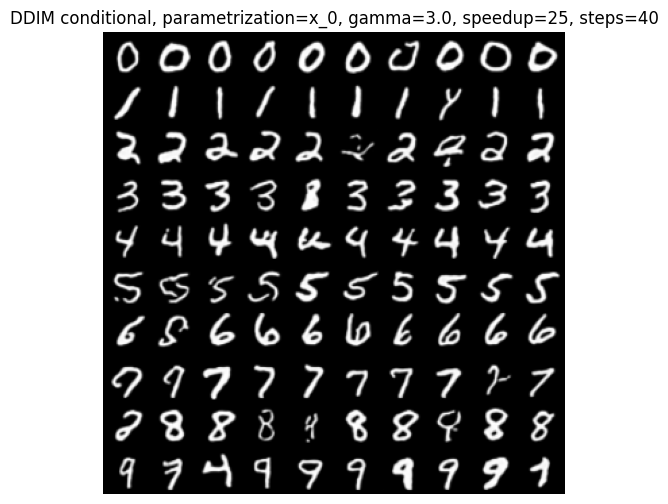

  0%|          | 0/20 [00:00<?, ?it/s]

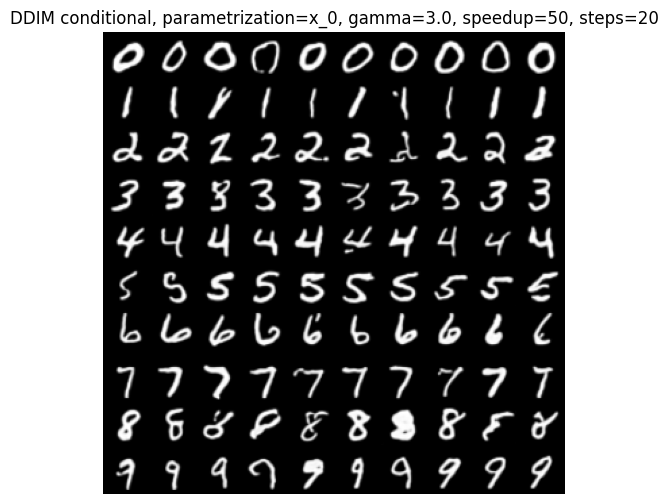

  0%|          | 0/10 [00:00<?, ?it/s]

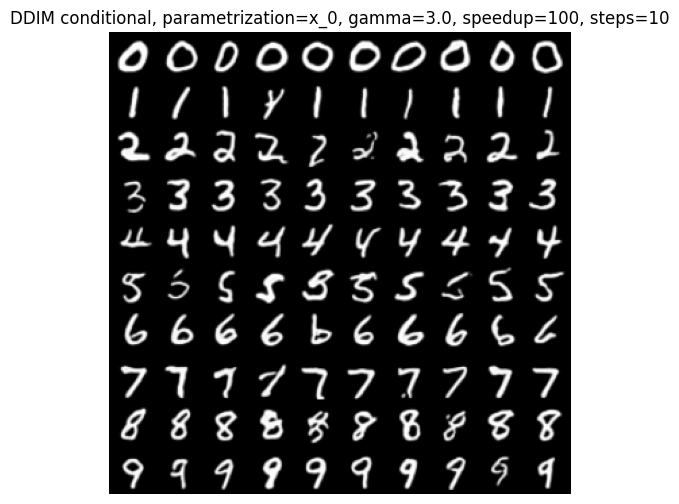

  0%|          | 0/5 [00:00<?, ?it/s]

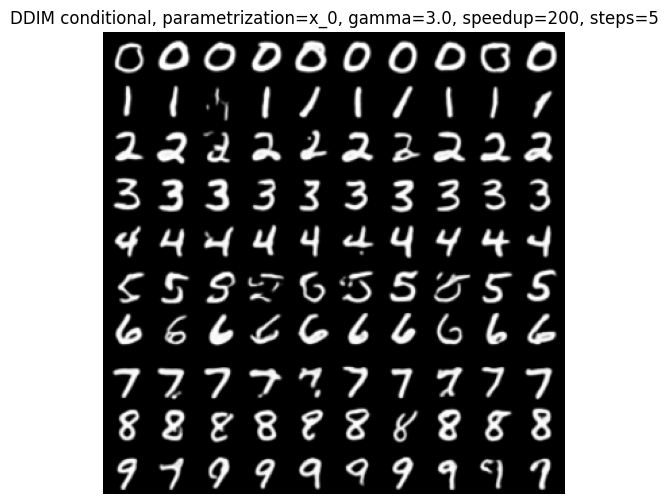

  0%|          | 0/200 [00:00<?, ?it/s]

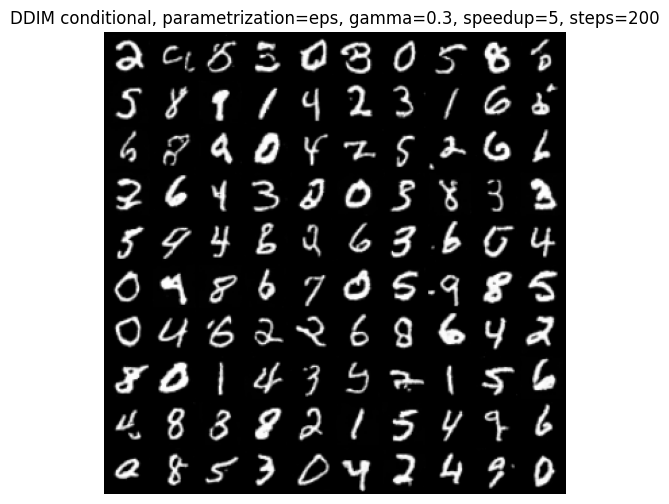

  0%|          | 0/100 [00:00<?, ?it/s]

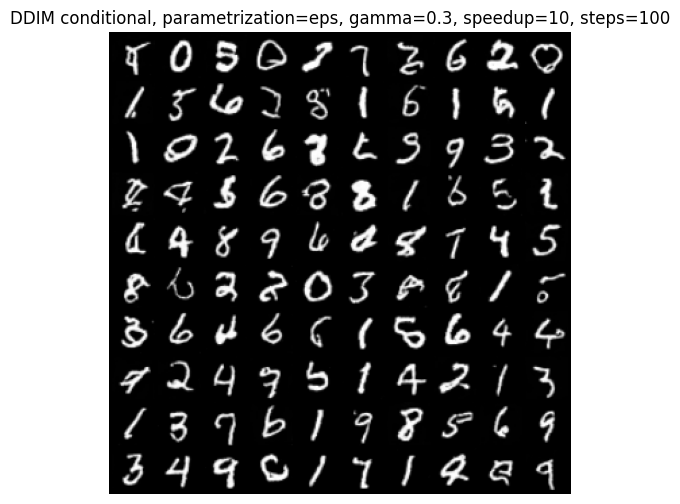

  0%|          | 0/40 [00:00<?, ?it/s]

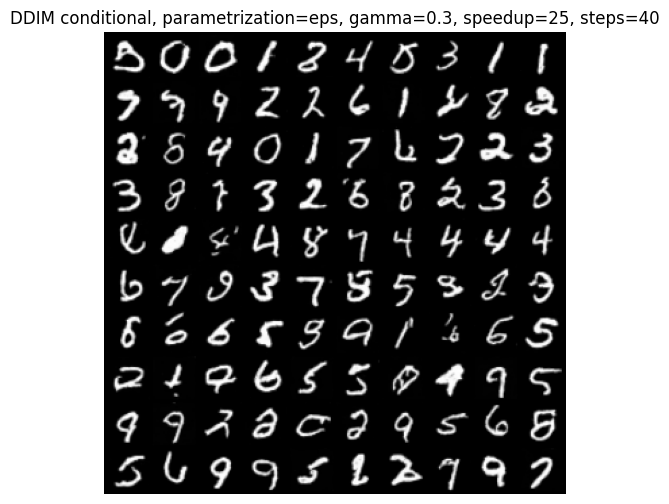

  0%|          | 0/20 [00:00<?, ?it/s]

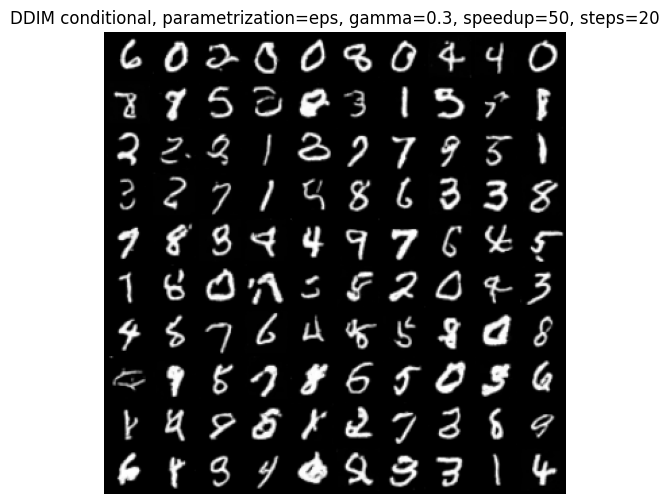

  0%|          | 0/10 [00:00<?, ?it/s]

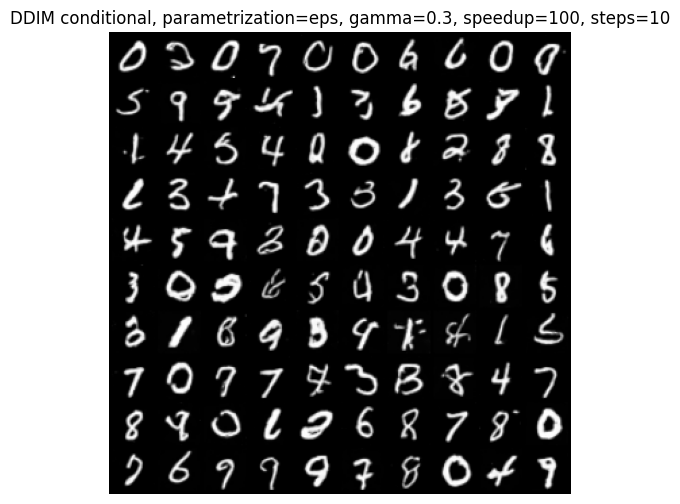

  0%|          | 0/5 [00:00<?, ?it/s]

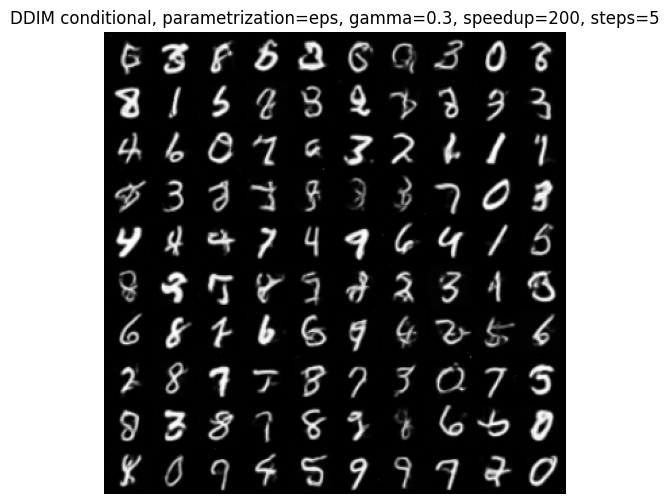

  0%|          | 0/200 [00:00<?, ?it/s]

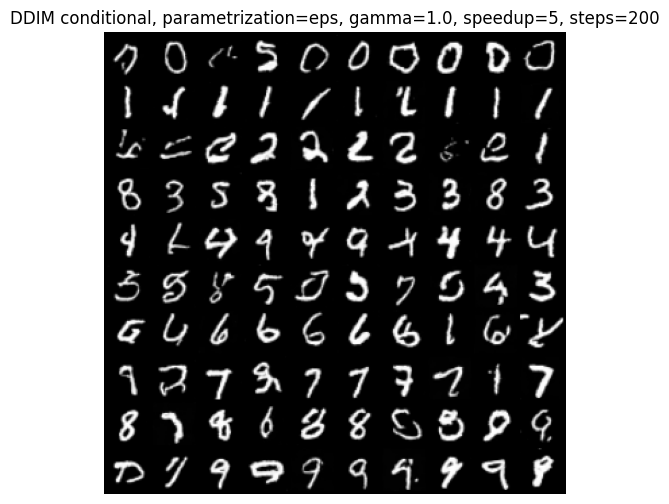

  0%|          | 0/100 [00:00<?, ?it/s]

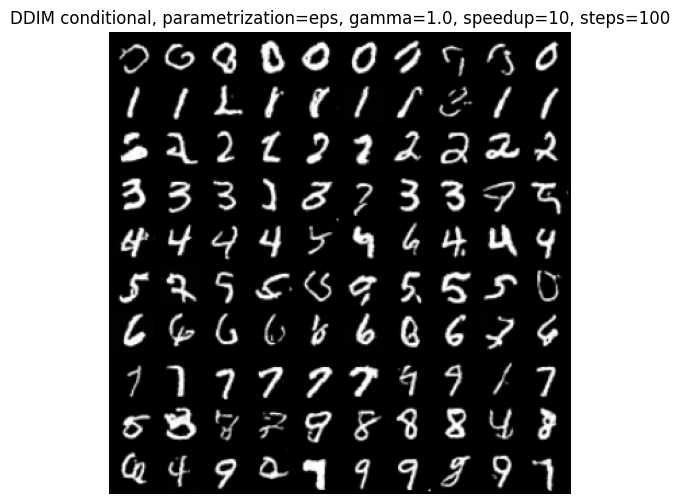

  0%|          | 0/40 [00:00<?, ?it/s]

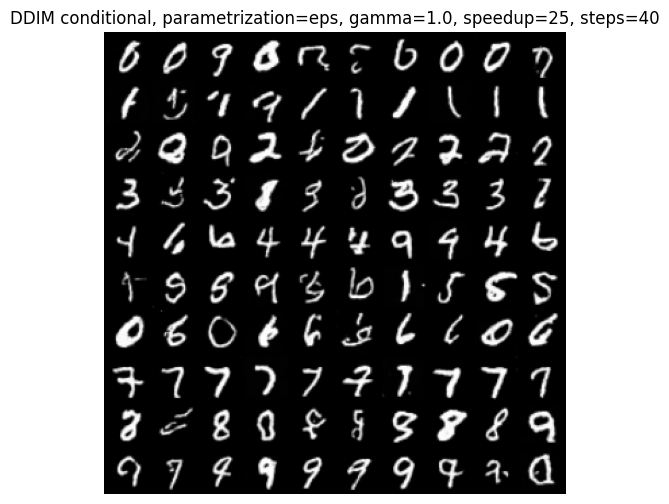

  0%|          | 0/20 [00:00<?, ?it/s]

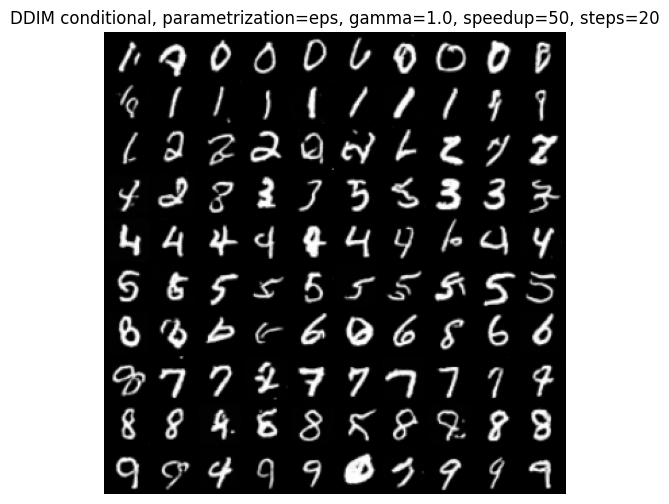

  0%|          | 0/10 [00:00<?, ?it/s]

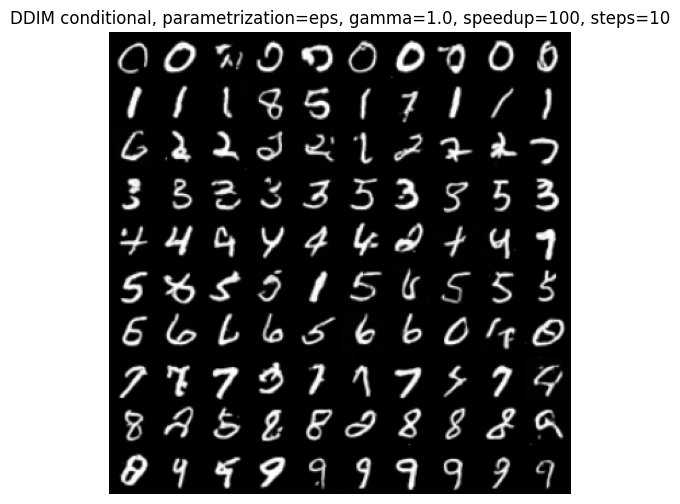

  0%|          | 0/5 [00:00<?, ?it/s]

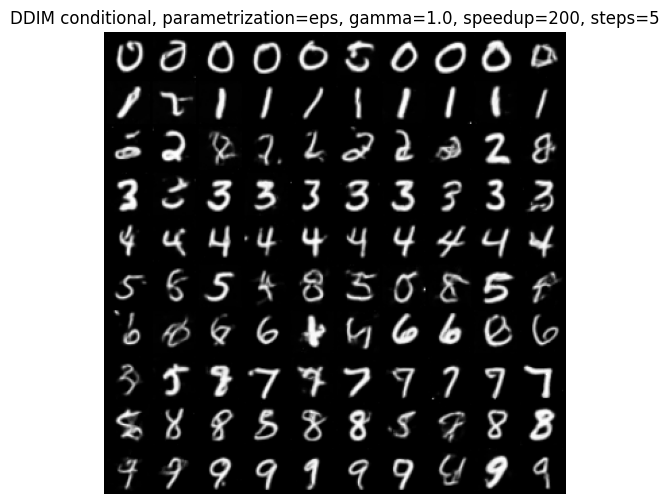

  0%|          | 0/200 [00:00<?, ?it/s]

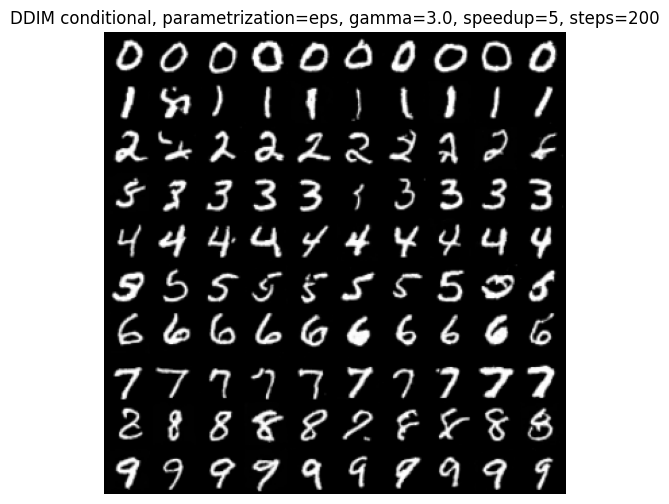

  0%|          | 0/100 [00:00<?, ?it/s]

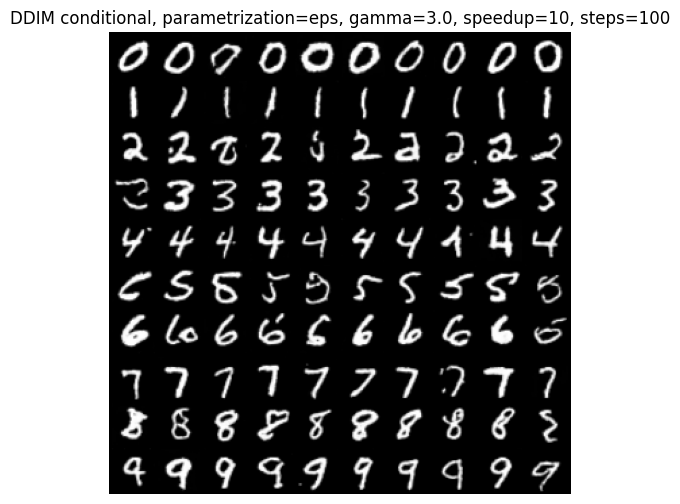

  0%|          | 0/40 [00:00<?, ?it/s]

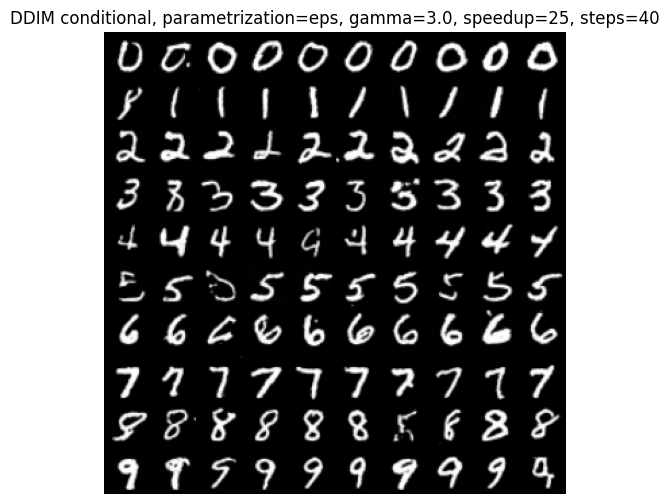

  0%|          | 0/20 [00:00<?, ?it/s]

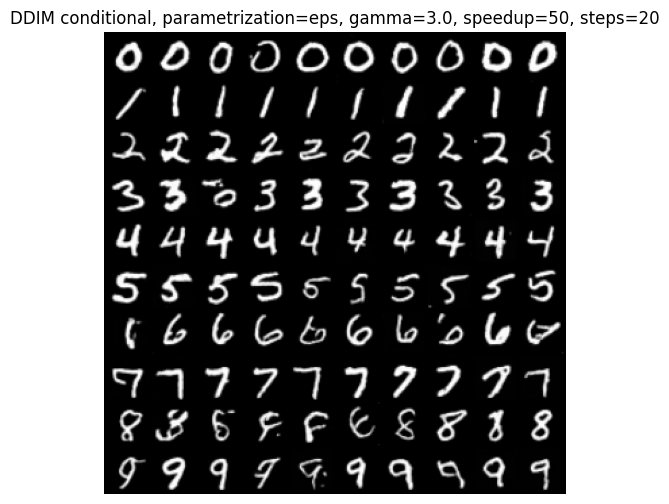

  0%|          | 0/10 [00:00<?, ?it/s]

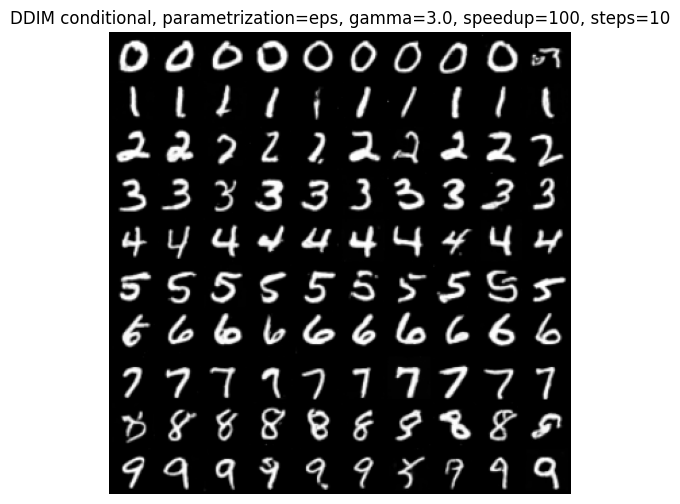

  0%|          | 0/5 [00:00<?, ?it/s]

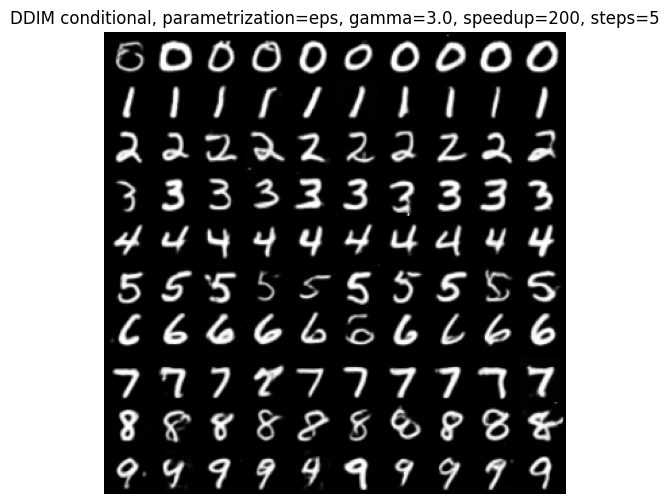

In [37]:
noisy_classifier.eval()

for parametrization, model in trained_ddpm_models.items():
    model.eval()
    for gamma in guidance_gammas:
        for speedup in speedups:
            sampler = make_ddim_cond_sampler(model, parametrization=parametrization, speedup=speedup, gamma=gamma, eta=0.0)
            grid = sample_images_with_cond(sampler, condition_100, device)
            schedule_len = len(sampler.make_schedule(device))
            show_grid(grid, f'DDIM conditional, parametrization={parametrization}, gamma={gamma}, speedup={speedup}, steps={schedule_len}')

You conclusion (3.6 pts):
* In what cases eps-parametrization is better than x_0 and vice-versa (indicate your generated images)
> eps performs better at higher gamma values, for example, eps with `gamma=3.0`, where the classes are almost perfectly preserved, but diversity decreases.
* How temperature influences on quality/divercity in your results (indicate)
> As gamma increases, the quality of the conditional generation improves: the numbers correspond more closely to the specified class. However, diversity decreases: in `eps`, with `gamma=3.0`, the rows become almost identical, meaning that mode collapse occurs.
* Why are you sure that your sampling in all cases is correct? How are you assure yourself in it's correctness? (explain your arguments how you debugged, arguments in style, - I got images correct, don't get scoring points)
> The posterior coefficients are updated using `torch.allclose`; the transitions between `eps` and `x_0` follow from the direct stochasticization formula; the time steps are taken in the correct reverse order